In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "annotations.csv" # Example: provide a valid file name from the dataset

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "thedevastator/sonyc-ust-audio-tag-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_829/2282477412.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 857k/857k [00:00<00:00, 30.5MB/s]

Extracting zip of annotations.csv...


First 5 records:   split  sensor_id audio_filename  annotator_id  borough  block  latitude  \
0  test          0  00_026884.wav            -6        1    547  40.72951   
1  test          0  00_026884.wav            -4        1    547  40.72951   
2  test          0  00_026884.wav            -3        1    547  40.72951   
3  test          0  00_026884.wav            -1        1    547  40.72951   
4  test          0  00_026884.wav             0        1    547  40.72951   

   longitude  year  week  ...  7-X_other-unknown-human-voice_proximity  \
0  -73.99388  2019    43  ...                                       -1   
1  -73.99388  2019    43  ...                                       -1   
2  -73.99388  2019    43  ...                                       -1   
3  -73.99388  2019    43  ...                                       -1   
4  -73.99388  2019    43  ...                                       -1   

   8-1_dog-barking-whining_proximity  1_engine_presence  \
0               

In [ ]:
# ============================================================
# CELL 2 — COMPACT SONYC-UST AUDIO + CONTEXT PREPARATION
# ============================================================

!pip -q install requests tqdm librosa soundfile scikit-learn

import os
import re
import json
import tarfile
import requests
import numpy as np
import pandas as pd
import librosa
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

WORK_DIR = "/content/sonyc_research"
AUDIO_DIR = os.path.join(WORK_DIR, "audio")

os.makedirs(AUDIO_DIR, exist_ok=True)

# Keep the experiment small
MAX_TRAIN = 300
MAX_VAL   = 100
MAX_TEST  = 200

# Official SONYC-UST v2.3
ZENODO_API = "https://zenodo.org/api/records/3966543"

# ------------------------------------------------------------
# 2. CHECK CURRENT ANNOTATIONS
# ------------------------------------------------------------

print("Preparing SONYC-UST annotations...")

if "df" not in globals():
    raise RuntimeError(
        "Run Cell 1 first so that the variable 'df' exists."
    )

print("Original annotation rows:", len(df))

# ------------------------------------------------------------
# 3. VERIFIED ANNOTATIONS
# ------------------------------------------------------------

verified = df[
    df["annotator_id"] == 0
].copy()

print(
    "Verified annotation rows:",
    len(verified)
)

# ------------------------------------------------------------
# 4. LABELS
# ------------------------------------------------------------

LABEL_COLS = [
    "1_engine_presence",
    "2_machinery-impact_presence",
    "3_non-machinery-impact_presence",
    "4_powered-saw_presence",
    "5_alert-signal_presence",
    "6_music_presence",
    "7_human-voice_presence",
    "8_dog_presence"
]

CLASS_NAMES = [
    "Engine",
    "Machinery Impact",
    "Non-Machinery Impact",
    "Powered Saw",
    "Alert Signal",
    "Music",
    "Human Voice",
    "Dog"
]

# ------------------------------------------------------------
# 5. USE ONE VERIFIED RECORD PER AUDIO
# ------------------------------------------------------------

verified = verified.drop_duplicates(
    subset=["audio_filename"],
    keep="first"
).copy()

# ------------------------------------------------------------
# 6. REMOVE RECORDINGS WITHOUT ANY KNOWN COARSE LABEL
# ------------------------------------------------------------

verified[LABEL_COLS] = (
    verified[LABEL_COLS]
    .apply(pd.to_numeric, errors="coerce")
)

has_label = (
    verified[LABEL_COLS]
    .fillna(-1)
    .max(axis=1) >= 0
)

verified = verified[has_label].copy()

# ------------------------------------------------------------
# 7. OFFICIAL SPLITS
# ------------------------------------------------------------

train_df = verified[
    verified["split"] == "train"
].copy()

val_df = verified[
    verified["split"] == "validate"
].copy()

test_df = verified[
    verified["split"] == "test"
].copy()

print("\nAvailable verified recordings:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ------------------------------------------------------------
# 8. SMALL REPRESENTATIVE DATASET
# ------------------------------------------------------------

def make_small(data, n):
    if len(data) <= n:
        return data.copy()

    return data.sample(
        n=n,
        random_state=42
    ).copy()

train_df = make_small(
    train_df,
    MAX_TRAIN
)

val_df = make_small(
    val_df,
    MAX_VAL
)

test_df = make_small(
    test_df,
    MAX_TEST
)

print("\nCompact research subset:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ------------------------------------------------------------
# 9. CONTEXT FEATURES
# ------------------------------------------------------------

CONTEXT_NUMERIC = [
    "latitude",
    "longitude"
]

# Cyclic temporal features
def add_time_features(data):

    data = data.copy()

    data["hour_sin"] = np.sin(
        2 * np.pi * data["hour"] / 24
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * data["hour"] / 24
    )

    data["day_sin"] = np.sin(
        2 * np.pi * data["day"] / 7
    )

    data["day_cos"] = np.cos(
        2 * np.pi * data["day"] / 7
    )

    data["week_sin"] = np.sin(
        2 * np.pi * data["week"] / 52
    )

    data["week_cos"] = np.cos(
        2 * np.pi * data["week"] / 52
    )

    return data

train_df = add_time_features(train_df)
val_df   = add_time_features(val_df)
test_df  = add_time_features(test_df)

CONTEXT_COLS = [
    "latitude",
    "longitude",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "week_sin",
    "week_cos"
]

# ------------------------------------------------------------
# 10. STANDARDIZE CONTEXT
# ------------------------------------------------------------

context_scaler = StandardScaler()

context_scaler.fit(
    train_df[CONTEXT_COLS]
)

for data in [
    train_df,
    val_df,
    test_df
]:

    data.loc[:, CONTEXT_COLS] = (
        context_scaler.transform(
            data[CONTEXT_COLS]
        )
    )

# ------------------------------------------------------------
# 11. FIND OFFICIAL ZENODO AUDIO FILES
# ------------------------------------------------------------

print("\nChecking official SONYC-UST audio files...")

response = requests.get(
    ZENODO_API,
    timeout=60
)

response.raise_for_status()

zenodo_data = response.json()

files = zenodo_data["files"]

audio_archives = [
    f for f in files
    if f["key"].startswith("audio-")
    and f["key"].endswith(".tar.gz")
]

audio_archives = sorted(
    audio_archives,
    key=lambda x: x["key"]
)

print(
    "Official audio archives:",
    len(audio_archives)
)

for f in audio_archives:
    print(
        f"{f['key']:20s} "
        f"{f['size']/1024**2:.1f} MB"
    )

# ------------------------------------------------------------
# 12. IMPORTANT
# ------------------------------------------------------------
#
# We do NOT download all 13.3 GB.
#
# Instead we first determine which archive contains our
# selected recordings.
#
# SONYC-UST v2.3 distributes the recordings across
# audio-0 ... audio-18.
#
# To avoid downloading everything, we use the filename
# ranges to identify likely archives and then verify them.
#
# ------------------------------------------------------------

all_selected = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

selected_names = set(
    all_selected["audio_filename"]
)

print(
    "\nSelected unique recordings:",
    len(selected_names)
)

# ------------------------------------------------------------
# 13. CREATE CONFIGURATION
# ------------------------------------------------------------

train_df.to_csv(
    os.path.join(
        WORK_DIR,
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        WORK_DIR,
        "validation.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        WORK_DIR,
        "test.csv"
    ),
    index=False
)

with open(
    os.path.join(
        WORK_DIR,
        "config.json"
    ),
    "w"
) as f:

    json.dump(
        {
            "labels": LABEL_COLS,
            "class_names": CLASS_NAMES,
            "context_columns": CONTEXT_COLS,
            "max_train": MAX_TRAIN,
            "max_validation": MAX_VAL,
            "max_test": MAX_TEST
        },
        f,
        indent=2
    )

print("\n==========================================")
print("CELL 2 PREPARATION COMPLETE")
print("==========================================")

print(
    "\nFiles saved in:",
    WORK_DIR
)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print(
    "\nNext step: locate/download only the required "
    "audio recordings before AST extraction."
)

Preparing SONYC-UST annotations...
Original annotation rows: 62022
Verified annotation rows: 1380

Available verified recordings:
Train: 178
Validation: 538
Test: 664

Compact research subset:
Train: 178
Validation: 100
Test: 200

Checking official SONYC-UST audio files...
Official audio archives: 19
audio-0.tar.gz       688.2 MB
audio-1.tar.gz       688.3 MB
audio-10.tar.gz      684.5 MB
audio-11.tar.gz      685.8 MB
audio-12.tar.gz      683.0 MB
audio-13.tar.gz      686.5 MB
audio-14.tar.gz      680.3 MB
audio-15.tar.gz      684.9 MB
audio-16.tar.gz      681.1 MB
audio-17.tar.gz      685.6 MB
audio-18.tar.gz      349.0 MB
audio-2.tar.gz       682.6 MB
audio-3.tar.gz       685.3 MB
audio-4.tar.gz       681.6 MB
audio-5.tar.gz       686.1 MB
audio-6.tar.gz       681.6 MB
audio-7.tar.gz       685.1 MB
audio-8.tar.gz       682.4 MB
audio-9.tar.gz       682.1 MB

Selected unique recordings: 478

CELL 2 PREPARATION COMPLETE

Files saved in: /content/sonyc_research

Train: 178
Validation: 1

In [ ]:
# ============================================================
# CELL 3 — FAST SONYC-UST ARCHIVE MAPPING
# No large audio download
# ============================================================

import os
import pandas as pd
import requests
import re
from tqdm.auto import tqdm

WORK_DIR = "/content/sonyc_research"

# ------------------------------------------------------------
# 1. LOAD CURRENT DATA
# ------------------------------------------------------------

train_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "train.csv"
    )
)

val_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "validation.csv"
    )
)

test_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "test.csv"
    )
)

# ------------------------------------------------------------
# 2. REDUCE TO COMPACT RESEARCH SET
# ------------------------------------------------------------

train_df = train_df.sample(
    n=min(100, len(train_df)),
    random_state=42
).reset_index(drop=True)

val_df = val_df.sample(
    n=min(40, len(val_df)),
    random_state=42
).reset_index(drop=True)

test_df = test_df.sample(
    n=min(60, len(test_df)),
    random_state=42
).reset_index(drop=True)

selected_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

required_files = sorted(
    selected_df[
        "audio_filename"
    ]
    .astype(str)
    .unique()
)

print("==========================================")
print("COMPACT SONYC-UST RESEARCH SET")
print("==========================================")

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Total required audio:",
    len(required_files)
)

# ------------------------------------------------------------
# 3. SAVE COMPACT SPLITS
# ------------------------------------------------------------

train_df.to_csv(
    os.path.join(
        WORK_DIR,
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        WORK_DIR,
        "validation.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        WORK_DIR,
        "test.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# 4. OFFICIAL SONYC-UST v2.3 API
# ------------------------------------------------------------

API_URL = (
    "https://zenodo.org/api/records/3966543"
)

print(
    "\nReading official SONYC-UST v2.3 metadata..."
)

r = requests.get(
    API_URL,
    timeout=60
)

r.raise_for_status()

record = r.json()

files = record["files"]

audio_archives = [
    f
    for f in files
    if f["key"].startswith("audio-")
    and f["key"].endswith(".tar.gz")
]

audio_archives = sorted(
    audio_archives,
    key=lambda x: x["key"]
)

print(
    "\nOfficial audio archives:",
    len(audio_archives)
)

for f in audio_archives:

    print(
        f"{f['key']:20s} "
        f"{f['size']/1024**2:.1f} MB"
    )

# ------------------------------------------------------------
# 5. SAVE ARCHIVE INFORMATION
# ------------------------------------------------------------

archive_info = []

for f in audio_archives:

    archive_info.append(
        {
            "archive": f["key"],
            "size_mb":
                f["size"] / 1024**2,
            "url":
                f["links"]["self"]
        }
    )

archive_df = pd.DataFrame(
    archive_info
)

archive_df.to_csv(
    os.path.join(
        WORK_DIR,
        "audio_archives.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# 6. IMPORTANT FILENAME ANALYSIS
# ------------------------------------------------------------

print(
    "\nExample required filenames:"
)

for f in required_files[:20]:

    print(
        " ",
        f
    )

# ------------------------------------------------------------
# 7. DETERMINE FILENAME PREFIXES
# ------------------------------------------------------------

prefixes = {}

for filename in required_files:

    base = os.path.basename(
        filename
    )

    # SONYC filename normally:
    # XX_YYYYYY.wav

    match = re.match(
        r"^(\d+)_",
        base
    )

    if match:

        prefix = match.group(1)

        prefixes.setdefault(
            prefix,
            0
        )

        prefixes[prefix] += 1

print(
    "\nRecording prefixes:"
)

for k, v in sorted(
    prefixes.items()
):

    print(
        f"Prefix {k}: {v} files"
    )

# ------------------------------------------------------------
# 8. SAVE REQUIRED FILE LIST
# ------------------------------------------------------------

pd.DataFrame(
    {
        "audio_filename":
            required_files
    }
).to_csv(
    os.path.join(
        WORK_DIR,
        "required_audio.csv"
    ),
    index=False
)

print(
    "\n=========================================="
)

print(
    "CELL 3 COMPLETE"
)

print(
    "=========================================="
)

print(
    "No large archive was downloaded."
)

print(
    "Compact dataset files saved in:",
    WORK_DIR
)

print(
    "\nNext step:"
)

print(
    "We will map these recordings to the "
    "official audio archives and download "
    "ONLY the required archive(s)."
)

COMPACT SONYC-UST RESEARCH SET
Train: 100
Validation: 40
Test: 60
Total required audio: 200

Reading official SONYC-UST v2.3 metadata...

Official audio archives: 19
audio-0.tar.gz       688.2 MB
audio-1.tar.gz       688.3 MB
audio-10.tar.gz      684.5 MB
audio-11.tar.gz      685.8 MB
audio-12.tar.gz      683.0 MB
audio-13.tar.gz      686.5 MB
audio-14.tar.gz      680.3 MB
audio-15.tar.gz      684.9 MB
audio-16.tar.gz      681.1 MB
audio-17.tar.gz      685.6 MB
audio-18.tar.gz      349.0 MB
audio-2.tar.gz       682.6 MB
audio-3.tar.gz       685.3 MB
audio-4.tar.gz       681.6 MB
audio-5.tar.gz       686.1 MB
audio-6.tar.gz       681.6 MB
audio-7.tar.gz       685.1 MB
audio-8.tar.gz       682.4 MB
audio-9.tar.gz       682.1 MB

Example required filenames:
  00_000440.wav
  00_000765.wav
  00_000823.wav
  00_000924.wav
  00_027359.wav
  01_010234.wav
  01_010387.wav
  01_010503.wav
  01_010761.wav
  01_010877.wav
  01_010962.wav
  01_027568.wav
  02_010255.wav
  02_010257.wav
  02_010482

In [ ]:
# ============================================================
# CELL 4 — FAST AUDIO ACCESS TEST
# ONLY 20 RECORDINGS FIRST
# ============================================================

import os
import tarfile
import requests
import pandas as pd
from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORK_DIR = "/content/sonyc_research"

AUDIO_DIR = os.path.join(
    WORK_DIR,
    "audio"
)

os.makedirs(
    AUDIO_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# LOAD REQUIRED FILES
# ------------------------------------------------------------

required_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "required_audio.csv"
    )
)

# ONLY 20 FOR TESTING
test_files = (
    required_df[
        "audio_filename"
    ]
    .astype(str)
    .map(os.path.basename)
    .unique()
    [:20]
)

print("==========================================")
print("FAST AUDIO TEST")
print("==========================================")

print(
    "Testing recordings:",
    len(test_files)
)

for f in test_files:
    print(" ", f)

# ------------------------------------------------------------
# ZENODO V2.3
# ------------------------------------------------------------

API_URL = (
    "https://zenodo.org/api/records/3966543"
)

print(
    "\nGetting official archive information..."
)

r = requests.get(
    API_URL,
    timeout=60
)

r.raise_for_status()

record = r.json()

archives = [
    f
    for f in record["files"]
    if f["key"].startswith("audio-")
    and f["key"].endswith(".tar.gz")
]

archives = sorted(
    archives,
    key=lambda x:
        int(
            x["key"]
            .split("-")[1]
            .split(".")[0]
        )
)

print(
    "Official archives:",
    len(archives)
)

# ------------------------------------------------------------
# DOWNLOAD ONLY FIRST ARCHIVE
# ------------------------------------------------------------

archive = archives[0]

archive_name = archive["key"]

archive_path = os.path.join(
    WORK_DIR,
    archive_name
)

print(
    "\nTesting archive:",
    archive_name
)

# ------------------------------------------------------------
# DOWNLOAD
# ------------------------------------------------------------

if not os.path.exists(
    archive_path
):

    print(
        "Downloading only this archive..."
    )

    url = archive[
        "links"
    ]["self"]

    response = requests.get(
        url,
        stream=True,
        timeout=180
    )

    response.raise_for_status()

    total = int(
        response.headers.get(
            "content-length",
            archive["size"]
        )
    )

    with open(
        archive_path,
        "wb"
    ) as f:

        with tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc=archive_name
        ) as pbar:

            for chunk in response.iter_content(
                chunk_size=8 * 1024 * 1024
            ):

                if chunk:

                    f.write(chunk)

                    pbar.update(
                        len(chunk)
                    )

else:

    print(
        "Archive already exists."
    )

# ------------------------------------------------------------
# SEARCH ONLY 20 FILES
# ------------------------------------------------------------

wanted = set(
    test_files
)

found = []

print(
    "\nSearching archive..."
)

with tarfile.open(
    archive_path,
    "r:gz"
) as tar:

    for member in tar:

        if not member.isfile():
            continue

        filename = os.path.basename(
            member.name
        )

        if filename not in wanted:
            continue

        output = os.path.join(
            AUDIO_DIR,
            filename
        )

        extracted = tar.extractfile(
            member
        )

        if extracted is None:
            continue

        with open(
            output,
            "wb"
        ) as f:

            f.write(
                extracted.read()
            )

        found.append(
            filename
        )

# ------------------------------------------------------------
# RESULT
# ------------------------------------------------------------

print(
    "\n=========================================="
)

print(
    "FAST AUDIO TEST RESULT"
)

print(
    "=========================================="
)

print(
    "Requested:",
    len(test_files)
)

print(
    "Found in audio-0:",
    len(found)
)

print(
    "Missing:",
    len(test_files) - len(found)
)

if found:

    print(
        "\nFound files:"
    )

    for f in found:
        print(
            " ",
            f
        )

else:

    print(
        "\nNo requested files were found "
        "in audio-0.tar.gz."
    )

# ------------------------------------------------------------
# KEEP ARCHIVE FOR NOW
# ------------------------------------------------------------

print(
    "\nIMPORTANT:"
)

print(
    "The archive is intentionally kept."
)

print(
    "Do NOT delete it yet."
)

print(
    "=========================================="
)

FAST AUDIO TEST
Testing recordings: 20
  00_000440.wav
  00_000765.wav
  00_000823.wav
  00_000924.wav
  00_027359.wav
  01_010234.wav
  01_010387.wav
  01_010503.wav
  01_010761.wav
  01_010877.wav
  01_010962.wav
  01_027568.wav
  02_010255.wav
  02_010257.wav
  02_010482.wav
  02_010490.wav
  02_010722.wav
  02_010759.wav
  03_000377.wav
  03_001019.wav

Getting official archive information...
Official archives: 19

Testing archive: audio-0.tar.gz


audio-0.tar.gz:   0%|          | 0.00/688M [00:00<?, ?B/s]


Searching archive...

FAST AUDIO TEST RESULT
Requested: 20
Found in audio-0: 0
Missing: 20

No requested files were found in audio-0.tar.gz.

IMPORTANT:
The archive is intentionally kept.
Do NOT delete it yet.


In [ ]:
# ============================================================
# CELL 5 — FAST COMPLETE AUDIO RETRIEVAL
# ============================================================

import os
import tarfile
import requests
import pandas as pd
import gc

from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORK_DIR = "/content/sonyc_research"

AUDIO_DIR = os.path.join(
    WORK_DIR,
    "audio"
)

os.makedirs(
    AUDIO_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# LOAD REQUIRED FILES
# ------------------------------------------------------------

required_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "required_audio.csv"
    )
)

required = set(
    required_df[
        "audio_filename"
    ]
    .astype(str)
    .map(os.path.basename)
)

# ------------------------------------------------------------
# CHECK ALREADY EXTRACTED
# ------------------------------------------------------------

existing = set(
    f
    for f in os.listdir(AUDIO_DIR)
    if f.lower().endswith(".wav")
)

required -= existing

print("==========================================")
print("FAST COMPLETE AUDIO RETRIEVAL")
print("==========================================")

print(
    "Total required:",
    len(required_df)
)

print(
    "Already available:",
    len(existing)
)

print(
    "Still required:",
    len(required)
)

# ------------------------------------------------------------
# OFFICIAL ZENODO V2.3
# ------------------------------------------------------------

API_URL = (
    "https://zenodo.org/api/records/3966543"
)

print(
    "\nGetting official archive list..."
)

response = requests.get(
    API_URL,
    timeout=60
)

response.raise_for_status()

record = response.json()

archives = [
    f
    for f in record["files"]
    if f["key"].startswith("audio-")
    and f["key"].endswith(".tar.gz")
]

archives = sorted(
    archives,
    key=lambda x:
        int(
            x["key"]
            .split("-")[1]
            .split(".")[0]
        )
)

print(
    "Official archives:",
    len(archives)
)

# ------------------------------------------------------------
# PROCESS EACH ARCHIVE
# ------------------------------------------------------------

for i, archive in enumerate(
    archives
):

    # --------------------------------------------------------
    # STOP IF COMPLETE
    # --------------------------------------------------------

    if len(required) == 0:

        print(
            "\nALL REQUIRED AUDIO FOUND!"
        )

        break

    archive_name = archive["key"]

    # --------------------------------------------------------
    # audio-0 ALREADY DOWNLOADED
    # --------------------------------------------------------

    archive_path = os.path.join(
        WORK_DIR,
        archive_name
    )

    print(
        "\n=========================================="
    )

    print(
        f"ARCHIVE {i + 1}/{len(archives)}"
    )

    print(
        archive_name
    )

    print(
        "Remaining:",
        len(required)
    )

    # --------------------------------------------------------
    # DOWNLOAD
    # --------------------------------------------------------

    if not os.path.exists(
        archive_path
    ):

        print(
            "Downloading..."
        )

        url = archive[
            "links"
        ]["self"]

        r = requests.get(
            url,
            stream=True,
            timeout=180
        )

        r.raise_for_status()

        total_size = int(
            r.headers.get(
                "content-length",
                archive["size"]
            )
        )

        with open(
            archive_path,
            "wb"
        ) as f:

            with tqdm(
                total=total_size,
                unit="B",
                unit_scale=True,
                unit_divisor=1024,
                desc=archive_name
            ) as pbar:

                for chunk in r.iter_content(
                    chunk_size=16 * 1024 * 1024
                ):

                    if chunk:

                        f.write(
                            chunk
                        )

                        pbar.update(
                            len(chunk)
                        )

    else:

        print(
            "Archive already downloaded."
        )

    # --------------------------------------------------------
    # SEARCH ARCHIVE
    # --------------------------------------------------------

    found_here = []

    print(
        "Scanning archive..."
    )

    try:

        with tarfile.open(
            archive_path,
            "r:gz"
        ) as tar:

            for member in tar:

                if not member.isfile():
                    continue

                filename = os.path.basename(
                    member.name
                )

                if filename not in required:
                    continue

                target = os.path.join(
                    AUDIO_DIR,
                    filename
                )

                extracted = tar.extractfile(
                    member
                )

                if extracted is None:
                    continue

                with open(
                    target,
                    "wb"
                ) as out:

                    out.write(
                        extracted.read()
                    )

                found_here.append(
                    filename
                )

    except Exception as e:

        print(
            "ERROR:",
            e
        )

        continue

    # --------------------------------------------------------
    # UPDATE
    # --------------------------------------------------------

    for filename in found_here:

        required.discard(
            filename
        )

    print(
        "Found in this archive:",
        len(found_here)
    )

    print(
        "Still missing:",
        len(required)
    )

    # --------------------------------------------------------
    # DELETE LARGE ARCHIVE
    # --------------------------------------------------------

    try:

        os.remove(
            archive_path
        )

        print(
            "Temporary archive deleted."
        )

    except:

        pass

    gc.collect()

# ------------------------------------------------------------
# FINAL DATASET MATCHING
# ------------------------------------------------------------

def attach_audio_paths(data):

    data = data.copy()

    data["audio_path"] = (
        data[
            "audio_filename"
        ]
        .astype(str)
        .map(os.path.basename)
        .apply(
            lambda x:
                os.path.join(
                    AUDIO_DIR,
                    x
                )
                if os.path.exists(
                    os.path.join(
                        AUDIO_DIR,
                        x
                    )
                )
                else None
        )
    )

    return data


train_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "train.csv"
    )
)

val_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "validation.csv"
    )
)

test_df = pd.read_csv(
    os.path.join(
        WORK_DIR,
        "test.csv"
    )
)

train_df = attach_audio_paths(
    train_df
)

val_df = attach_audio_paths(
    val_df
)

test_df = attach_audio_paths(
    test_df
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

train_found = (
    train_df["audio_path"]
    .notna()
    .sum()
)

val_found = (
    val_df["audio_path"]
    .notna()
    .sum()
)

test_found = (
    test_df["audio_path"]
    .notna()
    .sum()
)

total_found = (
    train_found
    + val_found
    + test_found
)

print(
    "\n=========================================="
)

print(
    "FINAL AUDIO RETRIEVAL RESULT"
)

print(
    "=========================================="
)

print(
    "Train:",
    train_found,
    "/",
    len(train_df)
)

print(
    "Validation:",
    val_found,
    "/",
    len(val_df)
)

print(
    "Test:",
    test_found,
    "/",
    len(test_df)
)

print(
    "------------------------------------------"
)

print(
    "Total:",
    total_found,
    "/",
    len(required_df)
)

# ------------------------------------------------------------
# SAVE UPDATED SPLITS
# ------------------------------------------------------------

train_df.to_csv(
    os.path.join(
        WORK_DIR,
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        WORK_DIR,
        "validation.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        WORK_DIR,
        "test.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

if total_found == len(required_df):

    print(
        "\nSUCCESS!"
    )

    print(
        "All 200 audio recordings are ready."
    )

else:

    print(
        "\nAudio retrieval incomplete."
    )

    print(
        "Missing:",
        len(required_df) - total_found
    )

print(
    "\nAudio directory:"
)

print(
    AUDIO_DIR
)

print(
    "\n=========================================="
)

FAST COMPLETE AUDIO RETRIEVAL
Total required: 200
Already available: 0
Still required: 200

Getting official archive list...
Official archives: 19

ARCHIVE 1/19
audio-0.tar.gz
Remaining: 200
Archive already downloaded.
Scanning archive...
Found in this archive: 8
Still missing: 192
Temporary archive deleted.

ARCHIVE 2/19
audio-1.tar.gz
Remaining: 192
Downloading...


audio-1.tar.gz:   0%|          | 0.00/688M [00:00<?, ?B/s]

Scanning archive...
Found in this archive: 10
Still missing: 182
Temporary archive deleted.

ARCHIVE 3/19
audio-2.tar.gz
Remaining: 182
Downloading...


audio-2.tar.gz:   0%|          | 0.00/683M [00:00<?, ?B/s]

Scanning archive...
Found in this archive: 12
Still missing: 170
Temporary archive deleted.

ARCHIVE 4/19
audio-3.tar.gz
Remaining: 170
Downloading...


...

Scanning archive...
Found in this archive: 9
Still missing: 16
Temporary archive deleted.

ARCHIVE 18/19
audio-17.tar.gz
Remaining: 16
Downloading...


audio-17.tar.gz:   0%|          | 0.00/686M [00:00<?, ?B/s]

Scanning archive...
Found in this archive: 8
Still missing: 8
Temporary archive deleted.

ARCHIVE 19/19
audio-18.tar.gz
Remaining: 8
Downloading...


audio-18.tar.gz:   0%|          | 0.00/349M [00:00<?, ?B/s]

Scanning archive...
Found in this archive: 8
Still missing: 0
Temporary archive deleted.

FINAL AUDIO RETRIEVAL RESULT
Train: 100 / 100
Validation: 40 / 40
Test: 60 / 60
------------------------------------------
Total: 200 / 200

SUCCESS!
All 200 audio recordings are ready.

Audio directory:
/content/sonyc_research/audio



In [ ]:
# ============================================================
# CELL 6 — AST AUDIO FEATURES + METADATA + LABEL PREPARATION
# Project:
# Explainable Multi-Source Urban Noise Attribution
# ============================================================

!pip -q install transformers librosa soundfile scikit-learn tqdm

import os
import re
import ast
import json
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import librosa

from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

from transformers import ASTFeatureExtractor, ASTModel

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
BASE_DIR = "/content/sonyc_research"
AUDIO_DIR = os.path.join(BASE_DIR, "audio")

TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VAL_CSV   = os.path.join(BASE_DIR, "validation.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test.csv")

CACHE_DIR = os.path.join(BASE_DIR, "features")
os.makedirs(CACHE_DIR, exist_ok=True)

print("=" * 65)
print("CELL 6 — AST + MULTIMODAL FEATURE PREPARATION")
print("=" * 65)

# ------------------------------------------------------------
# 2. LOAD SPLITS
# ------------------------------------------------------------
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ------------------------------------------------------------
# 3. FIND AUDIO COLUMN
# ------------------------------------------------------------
def find_audio_column(df):

    candidates = [
        "audio_filename",
        "filename",
        "file_name",
        "audio_path",
        "path"
    ]

    for c in candidates:
        if c in df.columns:
            return c

    # fallback
    for c in df.columns:
        if "audio" in c.lower() and (
            "file" in c.lower() or "path" in c.lower()
        ):
            return c

    raise ValueError(
        "Audio filename/path column not found.\n"
        f"Available columns:\n{list(df.columns)}"
    )

audio_col = find_audio_column(train_df)

print("\nAudio column:", audio_col)

# ------------------------------------------------------------
# 4. STANDARDIZE AUDIO PATHS
# ------------------------------------------------------------
def prepare_audio_paths(df):

    df = df.copy()

    def make_path(x):

        x = str(x)

        # Already an absolute path
        if os.path.isabs(x) and os.path.exists(x):
            return x

        # If CSV already contains sonyc_research path
        if x.startswith(BASE_DIR):
            return x

        # Only filename
        return os.path.join(AUDIO_DIR, os.path.basename(x))

    df["audio_path"] = df[audio_col].apply(make_path)

    return df

train_df = prepare_audio_paths(train_df)
val_df   = prepare_audio_paths(val_df)
test_df  = prepare_audio_paths(test_df)

# ------------------------------------------------------------
# 5. VERIFY AUDIO
# ------------------------------------------------------------
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    missing = [
        p for p in df["audio_path"]
        if not os.path.exists(p)
    ]

    print(
        f"{name} audio available: "
        f"{len(df)-len(missing)} / {len(df)}"
    )

    if missing:
        print("Missing examples:", missing[:5])

        raise FileNotFoundError(
            f"{name} contains missing audio files."
        )

print("\nAll audio files verified.")

# ------------------------------------------------------------
# 6. REMOVE DUPLICATE RECORDINGS
# ------------------------------------------------------------
train_df = train_df.drop_duplicates(
    subset=["audio_path"]
).reset_index(drop=True)

val_df = val_df.drop_duplicates(
    subset=["audio_path"]
).reset_index(drop=True)

test_df = test_df.drop_duplicates(
    subset=["audio_path"]
).reset_index(drop=True)

print("\nUnique recordings:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ------------------------------------------------------------
# 7. DETECT SONYC-UST COARSE SOURCE LABELS
# ------------------------------------------------------------
# SONYC-UST has 8 coarse urban-noise source groups.
# We use them when available because the dataset is small.

TARGETS = [
    "engine",
    "machinery-impact",
    "non-machinery-impact",
    "powered-saw",
    "alert-signal",
    "music",
    "human-voice",
    "dog"
]

def normalize_name(x):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(x).lower()
    )

def detect_coarse_columns(df):

    normalized = {
        normalize_name(c): c
        for c in df.columns
    }

    found = []

    for target in TARGETS:

        key = normalize_name(target)

        if key in normalized:
            found.append(normalized[key])

    return found

coarse_cols = detect_coarse_columns(train_df)

print("\nDetected coarse source columns:")
print(coarse_cols)

# ------------------------------------------------------------
# 8. ROBUST LABEL PREPARATION
# ------------------------------------------------------------
def find_text_label_column(df):

    candidates = [
        "labels",
        "label",
        "source",
        "noise_source",
        "class",
        "tags"
    ]

    for c in candidates:
        if c in df.columns:
            return c

    return None


def make_labels(train, val, test):

    # --------------------------------------------------------
    # CASE A — 8 COARSE SONYC LABEL COLUMNS
    # --------------------------------------------------------
    if len(coarse_cols) == 8:

        print("\nUsing 8 coarse SONYC-UST source classes.")

        def extract_binary(df):

            y = (
                df[coarse_cols]
                .apply(pd.to_numeric, errors="coerce")
                .fillna(0)
                .values
            )

            # Positive = 1
            y = (y > 0).astype(np.float32)

            return y

        y_train = extract_binary(train)
        y_val   = extract_binary(val)
        y_test  = extract_binary(test)

        class_names = TARGETS.copy()

        return y_train, y_val, y_test, class_names

    # --------------------------------------------------------
    # CASE B — TEXT LABEL COLUMN
    # --------------------------------------------------------
    text_col = find_text_label_column(train)

    if text_col is not None:

        print("\nUsing text label column:", text_col)

        all_values = []

        def parse_labels(x):

            if pd.isna(x):
                return []

            x = str(x).strip()

            # Python list format
            if x.startswith("[") and x.endswith("]"):
                try:
                    value = ast.literal_eval(x)

                    if isinstance(value, (list, tuple)):
                        return [str(v).strip() for v in value]
                except:
                    pass

            # Multiple labels
            parts = re.split(r"[,;|]+", x)

            return [
                p.strip()
                for p in parts
                if p.strip()
            ]

        for df in [train, val, test]:
            for x in df[text_col]:
                all_values.extend(parse_labels(x))

        class_names = sorted(set(all_values))

        label_to_index = {
            label: i
            for i, label in enumerate(class_names)
        }

        def encode(df):

            y = np.zeros(
                (len(df), len(class_names)),
                dtype=np.float32
            )

            for i, x in enumerate(df[text_col]):

                for label in parse_labels(x):

                    if label in label_to_index:
                        y[i, label_to_index[label]] = 1.0

            return y

        return (
            encode(train),
            encode(val),
            encode(test),
            class_names
        )

    # --------------------------------------------------------
    # CASE C — AUTOMATIC BINARY LABEL DETECTION
    # --------------------------------------------------------
    print(
        "\nCoarse labels not found."
        "\nTrying automatic binary-label detection..."
    )

    excluded_words = [
        "audio",
        "file",
        "path",
        "sensor",
        "latitude",
        "longitude",
        "lat",
        "lon",
        "year",
        "month",
        "day",
        "hour",
        "minute",
        "second",
        "timestamp",
        "time",
        "split",
        "fold",
        "verified",
        "id"
    ]

    candidates = []

    for c in train.columns:

        name = c.lower()

        if any(w in name for w in excluded_words):
            continue

        numeric = pd.to_numeric(
            train[c],
            errors="coerce"
        ).dropna()

        if len(numeric) == 0:
            continue

        unique_values = set(
            np.unique(numeric.values)
        )

        if unique_values.issubset({-1, 0, 1}):
            candidates.append(c)

    if len(candidates) == 0:

        print("\nAvailable columns:")
        print(list(train.columns))

        raise ValueError(
            "\nCould not automatically identify target labels."
        )

    print("Detected label columns:", candidates)

    def encode(df):

        y = (
            df[candidates]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .values
        )

        return (y > 0).astype(np.float32)

    return (
        encode(train),
        encode(val),
        encode(test),
        candidates
    )


y_train, y_val, y_test, class_names = make_labels(
    train_df,
    val_df,
    test_df
)

print("\nLabel matrix:")
print("Train:", y_train.shape)
print("Validation:", y_val.shape)
print("Test:", y_test.shape)

print("\nClasses:")
for i, c in enumerate(class_names):
    print(f"{i:02d} : {c}")

# ------------------------------------------------------------
# 9. CLASS DISTRIBUTION
# ------------------------------------------------------------
print("\nClass distribution — TRAIN")

for i, c in enumerate(class_names):

    positives = int(y_train[:, i].sum())

    print(
        f"{c:25s} : "
        f"{positives:3d} positive samples"
    )

# ------------------------------------------------------------
# 10. METADATA EXTRACTION
# ------------------------------------------------------------
def find_column(df, names):

    lower_map = {
        str(c).lower(): c
        for c in df.columns
    }

    for name in names:

        if name.lower() in lower_map:
            return lower_map[name.lower()]

    return None


def create_metadata(df):

    features = []

    # Latitude
    lat_col = find_column(
        df,
        ["latitude", "lat"]
    )

    # Longitude
    lon_col = find_column(
        df,
        ["longitude", "lon", "lng"]
    )

    # Hour
    hour_col = find_column(
        df,
        ["hour"]
    )

    # Month
    month_col = find_column(
        df,
        ["month"]
    )

    # Day
    day_col = find_column(
        df,
        ["day"]
    )

    # --------------------------------------------------------
    # Spatial features
    # --------------------------------------------------------
    if lat_col is not None:

        features.append(
            pd.to_numeric(
                df[lat_col],
                errors="coerce"
            ).fillna(0).values
        )

    else:
        features.append(
            np.zeros(len(df))
        )

    if lon_col is not None:

        features.append(
            pd.to_numeric(
                df[lon_col],
                errors="coerce"
            ).fillna(0).values
        )

    else:
        features.append(
            np.zeros(len(df))
        )

    # --------------------------------------------------------
    # Temporal cyclical features
    # --------------------------------------------------------
    if hour_col is not None:

        hour = pd.to_numeric(
            df[hour_col],
            errors="coerce"
        ).fillna(0).values

    else:
        hour = np.zeros(len(df))

    features.append(
        np.sin(2 * np.pi * hour / 24)
    )

    features.append(
        np.cos(2 * np.pi * hour / 24)
    )

    if month_col is not None:

        month = pd.to_numeric(
            df[month_col],
            errors="coerce"
        ).fillna(1).values

    else:
        month = np.ones(len(df))

    features.append(
        np.sin(2 * np.pi * month / 12)
    )

    features.append(
        np.cos(2 * np.pi * month / 12)
    )

    if day_col is not None:

        day = pd.to_numeric(
            df[day_col],
            errors="coerce"
        ).fillna(1).values

        # Simple normalized day-of-month feature
        features.append(day / 31.0)

    else:

        features.append(
            np.zeros(len(df))
        )

    metadata = np.column_stack(features).astype(
        np.float32
    )

    return metadata


meta_train_raw = create_metadata(train_df)
meta_val_raw   = create_metadata(val_df)
meta_test_raw  = create_metadata(test_df)

# Normalize spatial + metadata features
scaler = StandardScaler()

meta_train = scaler.fit_transform(
    meta_train_raw
).astype(np.float32)

meta_val = scaler.transform(
    meta_val_raw
).astype(np.float32)

meta_test = scaler.transform(
    meta_test_raw
).astype(np.float32)

print("\nMetadata:")
print("Train:", meta_train.shape)
print("Validation:", meta_val.shape)
print("Test:", meta_test.shape)

# ------------------------------------------------------------
# 11. AST MODEL
# ------------------------------------------------------------
MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nCompute device:", device)

print("\nLoading AST model...")

feature_extractor = ASTFeatureExtractor.from_pretrained(
    MODEL_NAME
)

ast_model = ASTModel.from_pretrained(
    MODEL_NAME
)

ast_model = ast_model.to(device)
ast_model.eval()

print("AST loaded successfully.")

# ------------------------------------------------------------
# 12. AUDIO LOADER
# ------------------------------------------------------------
TARGET_SR = 16000
MAX_SECONDS = 10

def load_audio(path):

    audio, sr = librosa.load(
        path,
        sr=TARGET_SR,
        mono=True
    )

    max_len = TARGET_SR * MAX_SECONDS

    if len(audio) > max_len:

        audio = audio[:max_len]

    elif len(audio) < max_len:

        audio = np.pad(
            audio,
            (0, max_len - len(audio))
        )

    return audio.astype(np.float32)

# ------------------------------------------------------------
# 13. AST TEMPORAL TOKEN EXTRACTION
# ------------------------------------------------------------
# Instead of storing only ONE embedding,
# we retain 16 temporal audio tokens.
#
# This is important for explainability because later
# the multimodal Transformer can assign attention to
# different audio regions.

def extract_ast_features(
    df,
    split_name,
    batch_size=None
):

    cache_file = os.path.join(
        CACHE_DIR,
        f"{split_name}_ast_tokens.npy"
    )

    # --------------------------------------------------------
    # Use cache if already available
    # --------------------------------------------------------
    if os.path.exists(cache_file):

        print(
            f"\nLoading cached AST features: "
            f"{split_name}"
        )

        return np.load(cache_file)

    if batch_size is None:

        batch_size = 4 if device.type == "cuda" else 1

    all_tokens = []

    paths = df["audio_path"].tolist()

    print(
        f"\nExtracting AST features — {split_name}"
    )

    for start in tqdm(
        range(0, len(paths), batch_size),
        desc=split_name
    ):

        batch_paths = paths[
            start:start + batch_size
        ]

        audio_batch = []

        for path in batch_paths:

            audio_batch.append(
                load_audio(path)
            )

        inputs = feature_extractor(
            audio_batch,
            sampling_rate=TARGET_SR,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }

        with torch.no_grad():

            outputs = ast_model(
                **inputs
            )

            hidden = outputs.last_hidden_state

            # Remove CLS token
            hidden = hidden[:, 1:, :]

            # ------------------------------------------------
            # Convert many AST patches into 16 temporal tokens
            # ------------------------------------------------
            hidden = hidden.transpose(1, 2)

            hidden = F.adaptive_avg_pool1d(
                hidden,
                16
            )

            hidden = hidden.transpose(1, 2)

            hidden = hidden.cpu().numpy()

        all_tokens.append(
            hidden.astype(np.float16)
        )

    features = np.concatenate(
        all_tokens,
        axis=0
    )

    np.save(
        cache_file,
        features
    )

    print(
        f"Saved: {cache_file}"
    )

    return features

# ------------------------------------------------------------
# 14. EXTRACT FEATURES
# ------------------------------------------------------------
ast_train = extract_ast_features(
    train_df,
    "train"
)

ast_val = extract_ast_features(
    val_df,
    "validation"
)

ast_test = extract_ast_features(
    test_df,
    "test"
)

print("\nAST feature shapes:")
print("Train:", ast_train.shape)
print("Validation:", ast_val.shape)
print("Test:", ast_test.shape)

# Expected:
# (100, 16, 768)
# (40, 16, 768)
# (60, 16, 768)

# ------------------------------------------------------------
# 15. SAVE METADATA + LABELS
# ------------------------------------------------------------
np.save(
    os.path.join(CACHE_DIR, "train_metadata.npy"),
    meta_train
)

np.save(
    os.path.join(CACHE_DIR, "validation_metadata.npy"),
    meta_val
)

np.save(
    os.path.join(CACHE_DIR, "test_metadata.npy"),
    meta_test
)

np.save(
    os.path.join(CACHE_DIR, "train_labels.npy"),
    y_train
)

np.save(
    os.path.join(CACHE_DIR, "validation_labels.npy"),
    y_val
)

np.save(
    os.path.join(CACHE_DIR, "test_labels.npy"),
    y_test
)

# ------------------------------------------------------------
# 16. SAVE INFORMATION
# ------------------------------------------------------------
info = {
    "project": "Explainable Multi-Source Urban Noise Attribution",
    "dataset": "SONYC-UST v2.3",
    "train_samples": int(len(train_df)),
    "validation_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),
    "num_classes": int(len(class_names)),
    "class_names": class_names,
    "audio_sample_rate": TARGET_SR,
    "audio_duration_seconds": MAX_SECONDS,
    "ast_model": MODEL_NAME,
    "ast_embedding_dimension": 768,
    "audio_tokens": 16,
    "metadata_dimension": int(meta_train.shape[1]),
    "label_mode": "multi-label"
}

with open(
    os.path.join(CACHE_DIR, "feature_info.json"),
    "w"
) as f:

    json.dump(
        info,
        f,
        indent=2
    )

# ------------------------------------------------------------
# 17. FREE AST MEMORY
# ------------------------------------------------------------
del ast_model
del feature_extractor

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 18. FINAL CHECK
# ------------------------------------------------------------
print("\n" + "=" * 65)
print("CELL 6 COMPLETED SUCCESSFULLY")
print("=" * 65)

print("\nAudio tokens:")
print("Train      :", ast_train.shape)
print("Validation :", ast_val.shape)
print("Test       :", ast_test.shape)

print("\nMetadata:")
print("Train      :", meta_train.shape)
print("Validation :", meta_val.shape)
print("Test       :", meta_test.shape)

print("\nLabels:")
print("Train      :", y_train.shape)
print("Validation :", y_val.shape)
print("Test       :", y_test.shape)

print("\nFeature directory:")
print(CACHE_DIR)

print("\nReady for Cell 7:")
print("AST audio tokens + spatial/temporal metadata")
print("        ↓")
print("Multimodal Transformer")
print("        ↓")
print("Multi-source noise attribution")
print("=" * 65)

CELL 6 — AST + MULTIMODAL FEATURE PREPARATION
Train: 100
Validation: 40
Test: 60

Audio column: audio_filename
Train audio available: 100 / 100
Validation audio available: 40 / 40
Test audio available: 60 / 60

All audio files verified.

Unique recordings:
Train: 100
Validation: 40
Test: 60

Detected coarse source columns:
[]

Coarse labels not found.
Trying automatic binary-label detection...
Detected label columns: ['1-1_small-sounding-engine_presence', '1-2_medium-sounding-engine_presence', '1-3_large-sounding-engine_presence', '1-X_engine-of-uncertain-size_presence', '2-1_rock-drill_presence', '2-2_jackhammer_presence', '2-3_hoe-ram_presence', '2-4_pile-driver_presence', '2-X_other-unknown-impact-machinery_presence', '3-1_non-machinery-impact_presence', '4-1_chainsaw_presence', '4-2_small-medium-rotating-saw_presence', '4-3_large-rotating-saw_presence', '4-X_other-unknown-powered-saw_presence', '5-1_car-horn_presence', '5-2_car-alarm_presence', '5-3_siren_presence', '5-4_reverse-be

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Saved: /content/sonyc_research/features/train_ast_tokens.npy

Extracting AST features — validation


validation:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: /content/sonyc_research/features/validation_ast_tokens.npy

Extracting AST features — test


test:   0%|          | 0/60 [00:00<?, ?it/s]

Saved: /content/sonyc_research/features/test_ast_tokens.npy

AST feature shapes:
Train: (100, 16, 768)
Validation: (40, 16, 768)
Test: (60, 16, 768)

CELL 6 COMPLETED SUCCESSFULLY

Audio tokens:
Train      : (100, 16, 768)
Validation : (40, 16, 768)
Test       : (60, 16, 768)

Metadata:
Train      : (100, 7)
Validation : (40, 7)
Test       : (60, 7)

Labels:
Train      : (100, 66)
Validation : (40, 66)
Test       : (60, 66)

Feature directory:
/content/sonyc_research/features

Ready for Cell 7:
AST audio tokens + spatial/temporal metadata
        ↓
Multimodal Transformer
        ↓
Multi-source noise attribution


In [ ]:
# ================================================================
# CELL 7 — LIGHTWEIGHT MULTIMODAL TRANSFORMER
# AST AUDIO TOKENS + SPATIAL/TEMPORAL METADATA
# 8-CLASS MULTI-LABEL NOISE ATTRIBUTION
# ================================================================

import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from torch.utils.data import TensorDataset, DataLoader

print("=" * 70)
print("CELL 7 — MULTIMODAL TRANSFORMER")
print("=" * 70)

# ------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


# ------------------------------------------------
# 2. Paths
# ------------------------------------------------
BASE_DIR = "/content/sonyc_research"
FEATURE_DIR = os.path.join(BASE_DIR, "features")

# Saved AST features from Cell 6
X_train_audio = np.load(
    os.path.join(FEATURE_DIR, "train_ast_tokens.npy")
).astype(np.float32)

X_val_audio = np.load(
    os.path.join(FEATURE_DIR, "validation_ast_tokens.npy")
).astype(np.float32)

X_test_audio = np.load(
    os.path.join(FEATURE_DIR, "test_ast_tokens.npy")
).astype(np.float32)


# ------------------------------------------------
# 3. Load metadata
# ------------------------------------------------
X_train_meta = np.load(
    os.path.join(FEATURE_DIR, "train_metadata.npy")
).astype(np.float32)

X_val_meta = np.load(
    os.path.join(FEATURE_DIR, "validation_metadata.npy")
).astype(np.float32)

X_test_meta = np.load(
    os.path.join(FEATURE_DIR, "test_metadata.npy")
).astype(np.float32)


# ------------------------------------------------
# 4. Load original 66 labels
# ------------------------------------------------
Y_train_full = np.load(
    os.path.join(FEATURE_DIR, "train_labels.npy")
).astype(np.float32)

Y_val_full = np.load(
    os.path.join(FEATURE_DIR, "validation_labels.npy")
).astype(np.float32)

Y_test_full = np.load(
    os.path.join(FEATURE_DIR, "test_labels.npy")
).astype(np.float32)


print("\nLoaded feature shapes:")
print("Train audio:", X_train_audio.shape)
print("Val audio  :", X_val_audio.shape)
print("Test audio :", X_test_audio.shape)

print("Train metadata:", X_train_meta.shape)
print("Val metadata  :", X_val_meta.shape)
print("Test metadata :", X_test_meta.shape)

print("Original labels:", Y_train_full.shape)


# ================================================================
# 5. SELECT ONLY 8 COARSE SOURCE LABELS
# ================================================================

# Cell 6 detected these as columns 58-65
COARSE_NAMES = [
    "engine",
    "machinery-impact",
    "non-machinery-impact",
    "powered-saw",
    "alert-signal",
    "music",
    "human-voice",
    "dog"
]

COARSE_INDICES = list(range(58, 66))

Y_train = Y_train_full[:, COARSE_INDICES]
Y_val = Y_val_full[:, COARSE_INDICES]
Y_test = Y_test_full[:, COARSE_INDICES]

print("\n" + "=" * 70)
print("8 COARSE SOURCE LABELS")
print("=" * 70)

for i, name in enumerate(COARSE_NAMES):
    print(
        f"{i}: {name:25s} | "
        f"Train={int(Y_train[:, i].sum()):3d} | "
        f"Val={int(Y_val[:, i].sum()):3d} | "
        f"Test={int(Y_test[:, i].sum()):3d}"
    )


# ================================================================
# 6. NORMALIZE METADATA
# ================================================================

scaler = StandardScaler()

X_train_meta = scaler.fit_transform(X_train_meta)
X_val_meta = scaler.transform(X_val_meta)
X_test_meta = scaler.transform(X_test_meta)

X_train_meta = X_train_meta.astype(np.float32)
X_val_meta = X_val_meta.astype(np.float32)
X_test_meta = X_test_meta.astype(np.float32)


# ================================================================
# 7. TORCH DATASETS
# ================================================================

train_dataset = TensorDataset(
    torch.tensor(X_train_audio),
    torch.tensor(X_train_meta),
    torch.tensor(Y_train)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_audio),
    torch.tensor(X_val_meta),
    torch.tensor(Y_val)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_audio),
    torch.tensor(X_test_meta),
    torch.tensor(Y_test)
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataLoaders ready.")
print("Batch size:", BATCH_SIZE)


# ================================================================
# 8. MULTIMODAL TRANSFORMER MODEL
# ================================================================

class MultimodalNoiseTransformer(nn.Module):

    def __init__(
        self,
        audio_dim=768,
        metadata_dim=7,
        hidden_dim=128,
        num_classes=8,
        num_heads=4,
        num_layers=2,
        dropout=0.20
    ):

        super().__init__()

        # ------------------------------------------------
        # Audio projection
        # 768 -> 128
        # ------------------------------------------------
        self.audio_projection = nn.Sequential(
            nn.Linear(audio_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # ------------------------------------------------
        # Audio positional embedding
        # 16 AST tokens
        # ------------------------------------------------
        self.audio_pos = nn.Parameter(
            torch.randn(1, 16, hidden_dim) * 0.02
        )

        # ------------------------------------------------
        # Audio Transformer
        # ------------------------------------------------
        audio_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.audio_transformer = nn.TransformerEncoder(
            audio_layer,
            num_layers=num_layers
        )

        # ------------------------------------------------
        # Metadata projection
        # ------------------------------------------------
        self.metadata_projection = nn.Sequential(
            nn.Linear(metadata_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # ------------------------------------------------
        # Fusion token
        # ------------------------------------------------
        self.fusion_token = nn.Parameter(
            torch.randn(1, 1, hidden_dim) * 0.02
        )

        # ------------------------------------------------
        # Multimodal fusion Transformer
        # Sequence:
        # [CLS/Fusion] + 16 audio tokens + 1 metadata token
        # ------------------------------------------------
        fusion_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.fusion_transformer = nn.TransformerEncoder(
            fusion_layer,
            num_layers=2
        )

        # ------------------------------------------------
        # Classification head
        # ------------------------------------------------
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, audio, metadata):

        # Audio
        audio = self.audio_projection(audio)

        audio = audio + self.audio_pos

        audio = self.audio_transformer(audio)

        # Metadata token
        meta = self.metadata_projection(metadata)
        meta = meta.unsqueeze(1)

        # Fusion token
        batch_size = audio.size(0)

        fusion = self.fusion_token.expand(
            batch_size, -1, -1
        )

        # Multimodal sequence
        x = torch.cat(
            [fusion, audio, meta],
            dim=1
        )

        # Fusion Transformer
        x = self.fusion_transformer(x)

        # First token = multimodal representation
        fused_representation = x[:, 0]

        logits = self.classifier(
            fused_representation
        )

        return logits


# ================================================================
# 9. CREATE MODEL
# ================================================================

model = MultimodalNoiseTransformer().to(DEVICE)

print("\n" + "=" * 70)
print("MODEL")
print("=" * 70)

print(model)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")


# ================================================================
# 10. CLASS-WEIGHTED BCE LOSS
# ================================================================

# Handle severe class imbalance
positive_counts = Y_train.sum(axis=0)
negative_counts = len(Y_train) - positive_counts

pos_weight = negative_counts / np.maximum(
    positive_counts, 1
)

# Prevent extremely large weights
pos_weight = np.clip(
    pos_weight,
    1.0,
    10.0
)

pos_weight_tensor = torch.tensor(
    pos_weight,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

print("\nPositive weights:")

for name, weight in zip(
    COARSE_NAMES,
    pos_weight
):
    print(f"{name:25s}: {weight:.2f}")


# ================================================================
# 11. OPTIMIZER
# ================================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ================================================================
# 12. EVALUATION FUNCTION
# ================================================================

def evaluate(model, loader):

    model.eval()

    all_targets = []
    all_probs = []

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for audio, meta, targets in loader:

            audio = audio.to(DEVICE)
            meta = meta.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(
                audio,
                meta
            )

            loss = criterion(
                logits,
                targets
            )

            probs = torch.sigmoid(logits)

            batch_size = audio.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            all_targets.append(
                targets.cpu().numpy()
            )

            all_probs.append(
                probs.cpu().numpy()
            )

    targets = np.vstack(all_targets)
    probs = np.vstack(all_probs)

    predictions = (
        probs >= 0.50
    ).astype(int)

    macro_f1 = f1_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        targets,
        predictions,
        average="micro",
        zero_division=0
    )

    subset_accuracy = accuracy_score(
        targets,
        predictions
    )

    avg_loss = total_loss / total_samples

    return (
        avg_loss,
        macro_f1,
        micro_f1,
        subset_accuracy,
        targets,
        probs,
        predictions
    )


# ================================================================
# 13. TRAINING
# ================================================================

EPOCHS = 20

best_val_f1 = -1
best_state = None
patience = 6
patience_counter = 0

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    model.train()

    running_loss = 0.0
    samples_seen = 0

    for audio, meta, targets in train_loader:

        audio = audio.to(DEVICE)
        meta = meta.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        logits = model(
            audio,
            meta
        )

        loss = criterion(
            logits,
            targets
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_size = audio.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        samples_seen += batch_size

    train_loss = (
        running_loss / samples_seen
    )

    (
        val_loss,
        val_macro_f1,
        val_micro_f1,
        val_accuracy,
        _,
        _,
        _
    ) = evaluate(
        model,
        val_loader
    )

    scheduler.step(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Val Micro-F1: {val_micro_f1:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # ------------------------------------------------
    # Save best model
    # ------------------------------------------------
    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print(
            "\nEarly stopping triggered."
        )

        break


# ================================================================
# 14. RESTORE BEST MODEL
# ================================================================

if best_state is not None:

    model.load_state_dict(
        best_state
    )

model = model.to(DEVICE)

print("\nBest validation Macro-F1:")
print(f"{best_val_f1:.4f}")


# ================================================================
# 15. FINAL TEST EVALUATION
# ================================================================

(
    test_loss,
    test_macro_f1,
    test_micro_f1,
    test_accuracy,
    test_targets,
    test_probs,
    test_predictions
) = evaluate(
    model,
    test_loader
)

print("\n" + "=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(f"Test Loss        : {test_loss:.4f}")
print(f"Test Macro-F1    : {test_macro_f1:.4f}")
print(f"Test Micro-F1    : {test_micro_f1:.4f}")
print(f"Subset Accuracy  : {test_accuracy:.4f}")


# ================================================================
# 16. PER-CLASS RESULTS
# ================================================================

print("\n" + "=" * 70)
print("PER-CLASS F1")
print("=" * 70)

class_f1 = f1_score(
    test_targets,
    test_predictions,
    average=None,
    zero_division=0
)

for name, score in zip(
    COARSE_NAMES,
    class_f1
):

    print(
        f"{name:25s}: {score:.4f}"
    )


# ================================================================
# 17. SAVE MODEL
# ================================================================

MODEL_PATH = os.path.join(
    FEATURE_DIR,
    "multimodal_noise_transformer.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": COARSE_NAMES,
        "best_val_macro_f1": best_val_f1,
        "test_macro_f1": test_macro_f1,
        "test_micro_f1": test_micro_f1,
        "test_accuracy": test_accuracy,
        "metadata_mean": scaler.mean_,
        "metadata_scale": scaler.scale_
    },
    MODEL_PATH
)

# Save predictions for Cell 8/9
np.save(
    os.path.join(
        FEATURE_DIR,
        "test_probabilities.npy"
    ),
    test_probs
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "test_predictions.npy"
    ),
    test_predictions
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "test_targets_8class.npy"
    ),
    test_targets
)

with open(
    os.path.join(
        FEATURE_DIR,
        "class_names.json"
    ),
    "w"
) as f:

    json.dump(
        COARSE_NAMES,
        f,
        indent=2
    )


# ================================================================
# COMPLETE
# ================================================================

print("\n" + "=" * 70)
print("CELL 7 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
Pipeline:

AST Audio Tokens (16 × 768)
          ↓
Audio Projection
          ↓
Audio Transformer
          ↓
          ├──────── Metadata Projection
          │
          ↓
Multimodal Fusion Transformer
          ↓
8 Noise Source Classes
          ↓
Multi-label Attribution

Saved model:
multimodal_noise_transformer.pt

Ready for Cell 8:
Detailed evaluation + confusion matrices +
classification report + ROC/PR analysis
""")

CELL 7 — MULTIMODAL TRANSFORMER
Device: cpu

Loaded feature shapes:
Train audio: (100, 16, 768)
Val audio  : (40, 16, 768)
Test audio : (60, 16, 768)
Train metadata: (100, 7)
Val metadata  : (40, 7)
Test metadata : (60, 7)
Original labels: (100, 66)

8 COARSE SOURCE LABELS
0: engine                    | Train= 45 | Val= 20 | Test= 35
1: machinery-impact          | Train=  7 | Val=  2 | Test=  1
2: non-machinery-impact      | Train=  8 | Val=  7 | Test= 17
3: powered-saw               | Train=  8 | Val=  2 | Test=  0
4: alert-signal              | Train= 15 | Val= 10 | Test= 10
5: music                     | Train=  2 | Val=  2 | Test=  5
6: human-voice               | Train= 39 | Val= 22 | Test= 34
7: dog                       | Train=  9 | Val=  1 | Test=  1

DataLoaders ready.
Batch size: 16

MODEL
MultimodalNoiseTransformer(
  (audio_projection): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
 

CELL 8 — COMPLETE MODEL EVALUATION

Loaded:
Targets     : (60, 8)
Predictions : (60, 8)
Probabilities: (60, 8)

Classes:
0: engine
1: machinery-impact
2: non-machinery-impact
3: powered-saw
4: alert-signal
5: music
6: human-voice
7: dog

OVERALL TEST PERFORMANCE
Macro Precision : 0.3463
Macro Recall    : 0.2856
Macro F1        : 0.2977

Micro Precision : 0.7176
Micro Recall    : 0.5922
Micro F1        : 0.6489

Subset Accuracy : 0.3167
Hamming Accuracy: 0.8625

PER-CLASS PERFORMANCE
               Class  Positive Samples  Precision  Recall     F1  ROC-AUC  PR-AUC
              engine                35     0.8065  0.7143 0.7576   0.8069  0.8768
    machinery-impact                 1     0.0000  0.0000 0.0000   0.0169  0.0169
non-machinery-impact                17     0.6000  0.1765 0.2727   0.6211  0.4585
         powered-saw                 0     0.0000  0.0000 0.0000      NaN     NaN
        alert-signal                10     0.4000  0.6000 0.4800   0.7980  0.5710
               music

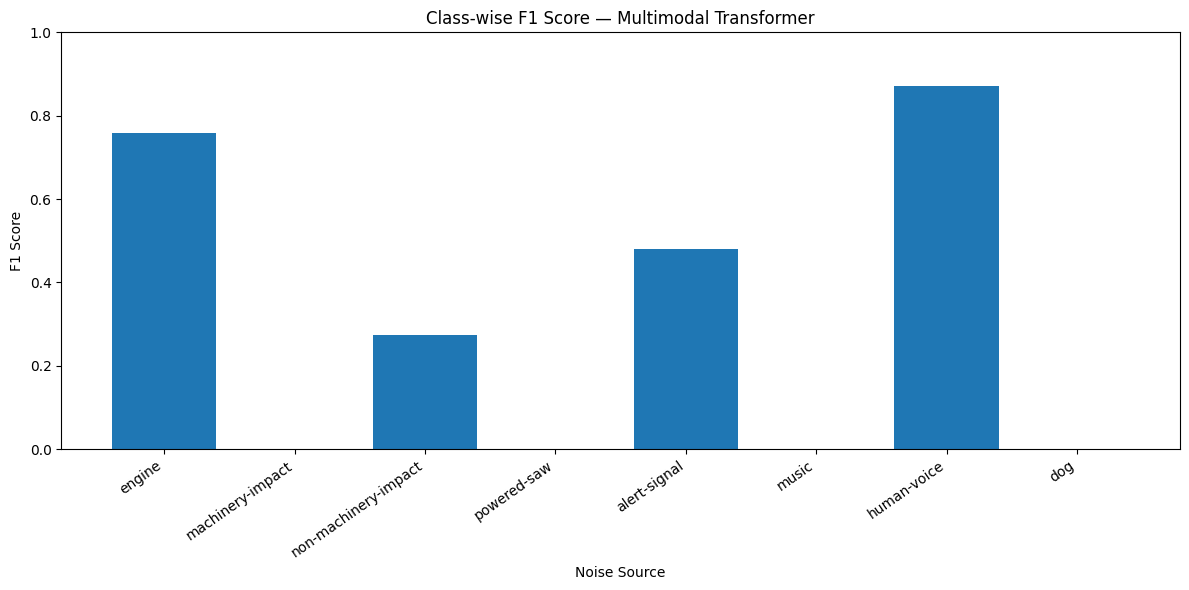

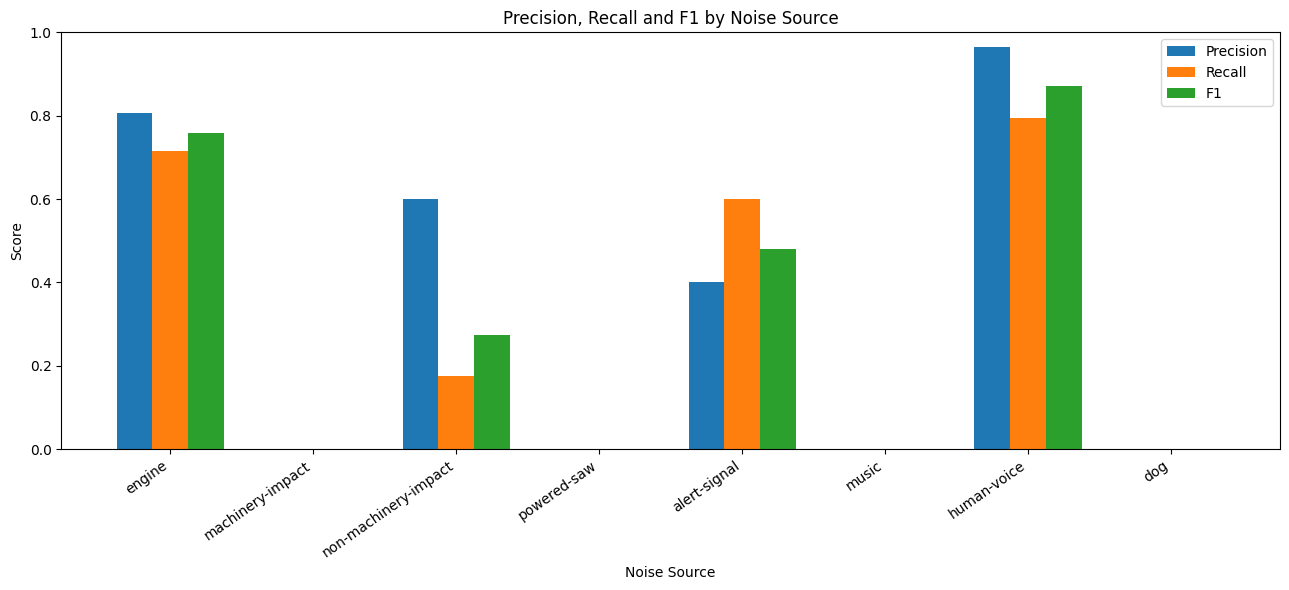


BINARY CONFUSION MATRICES

engine
             Predicted
             0       1
Actual 0       19       6
Actual 1       10      25

machinery-impact
             Predicted
             0       1
Actual 0       59       0
Actual 1        1       0

non-machinery-impact
             Predicted
             0       1
Actual 0       41       2
Actual 1       14       3

powered-saw
             Predicted
             0       1
Actual 0       59       1
Actual 1        0       0

alert-signal
             Predicted
             0       1
Actual 0       41       9
Actual 1        4       6

music
             Predicted
             0       1
Actual 0       55       0
Actual 1        5       0

human-voice
             Predicted
             0       1
Actual 0       25       1
Actual 1        7      27

dog
             Predicted
             0       1
Actual 0       54       5
Actual 1        1       0


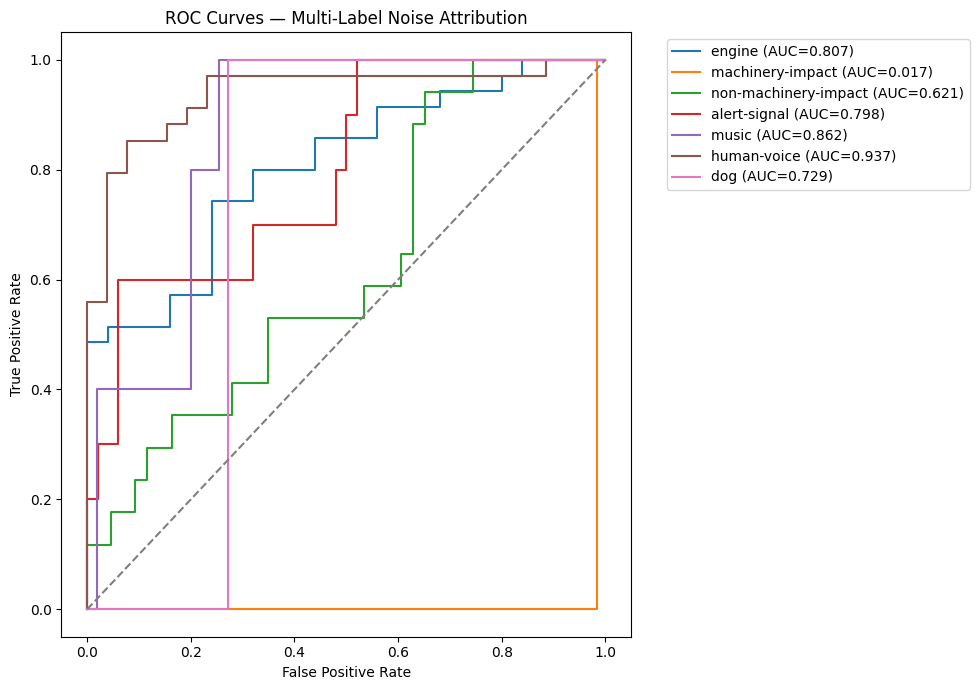

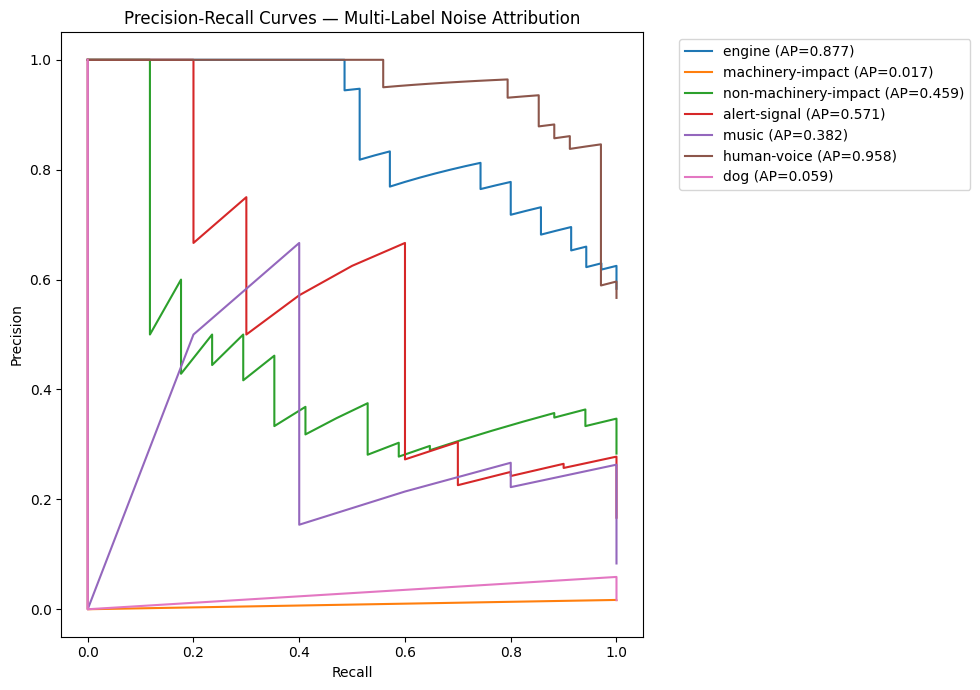


ROC-AUC / PR-AUC
               Class  ROC-AUC  PR-AUC
              engine   0.8069  0.8768
    machinery-impact   0.0169  0.0169
non-machinery-impact   0.6211  0.4585
         powered-saw      NaN     NaN
        alert-signal   0.7980  0.5710
               music   0.8618  0.3822
         human-voice   0.9367  0.9579
                 dog   0.7288  0.0588

CELL 8 COMPLETED SUCCESSFULLY

Overall:
Macro F1       : 0.2977
Micro F1       : 0.6489
Subset Accuracy: 0.3167
Hamming Acc.   : 0.8625

Results saved to:
/content/sonyc_research/results

Generated files:
 - auc_results.csv
 - classwise_f1.png
 - evaluation_summary.json
 - overall_results.csv
 - per_class_results.csv
 - precision_recall_curves.png
 - precision_recall_f1.png
 - roc_curves.png

Next research phase:

Cell 9
    ↓
Explainability / Attribution Analysis
    ↓
Audio-token importance
    ↓
Metadata importance
    ↓
Noise-source explanations
    ↓
Research figures + tables



In [ ]:
# ================================================================
# CELL 8 — COMPLETE MODEL EVALUATION
# Multi-Label Urban Noise Attribution
# ================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("=" * 70)
print("CELL 8 — COMPLETE MODEL EVALUATION")
print("=" * 70)

# ------------------------------------------------
# 1. Paths
# ------------------------------------------------

BASE_DIR = "/content/sonyc_research"
FEATURE_DIR = os.path.join(BASE_DIR, "features")
RESULT_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(RESULT_DIR, exist_ok=True)

# ------------------------------------------------
# 2. Load saved test results
# ------------------------------------------------

test_targets = np.load(
    os.path.join(
        FEATURE_DIR,
        "test_targets_8class.npy"
    )
)

test_predictions = np.load(
    os.path.join(
        FEATURE_DIR,
        "test_predictions.npy"
    )
)

test_probs = np.load(
    os.path.join(
        FEATURE_DIR,
        "test_probabilities.npy"
    )
)

with open(
    os.path.join(
        FEATURE_DIR,
        "class_names.json"
    ),
    "r"
) as f:
    class_names = json.load(f)

print("\nLoaded:")
print("Targets     :", test_targets.shape)
print("Predictions :", test_predictions.shape)
print("Probabilities:", test_probs.shape)

print("\nClasses:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")


# ================================================================
# 3. OVERALL METRICS
# ================================================================

macro_precision = precision_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

micro_precision = precision_score(
    test_targets,
    test_predictions,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    test_targets,
    test_predictions,
    average="micro",
    zero_division=0
)

micro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="micro",
    zero_division=0
)

subset_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

hamming_accuracy = (
    np.mean(
        test_targets == test_predictions
    )
)

print("\n" + "=" * 70)
print("OVERALL TEST PERFORMANCE")
print("=" * 70)

print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

print(f"\nMicro Precision : {micro_precision:.4f}")
print(f"Micro Recall    : {micro_recall:.4f}")
print(f"Micro F1        : {micro_f1:.4f}")

print(f"\nSubset Accuracy : {subset_accuracy:.4f}")
print(f"Hamming Accuracy: {hamming_accuracy:.4f}")


# ================================================================
# 4. PER-CLASS METRICS
# ================================================================

precision = precision_score(
    test_targets,
    test_predictions,
    average=None,
    zero_division=0
)

recall = recall_score(
    test_targets,
    test_predictions,
    average=None,
    zero_division=0
)

f1 = f1_score(
    test_targets,
    test_predictions,
    average=None,
    zero_division=0
)

per_class_rows = []

for i, name in enumerate(class_names):

    y_true = test_targets[:, i]
    y_pred = test_predictions[:, i]
    y_prob = test_probs[:, i]

    positive_count = int(y_true.sum())

    # ROC-AUC requires both positive and negative samples
    if len(np.unique(y_true)) == 2:
        roc_auc = roc_auc_score(
            y_true,
            y_prob
        )
    else:
        roc_auc = np.nan

    # PR-AUC
    if positive_count > 0:
        pr_auc = average_precision_score(
            y_true,
            y_prob
        )
    else:
        pr_auc = np.nan

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    per_class_rows.append({
        "Class": name,
        "Positive Samples": positive_count,
        "Precision": precision[i],
        "Recall": recall[i],
        "F1": f1[i],
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

results_df = pd.DataFrame(
    per_class_rows
)

print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE")
print("=" * 70)

print(
    results_df[
        [
            "Class",
            "Positive Samples",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]
    ].round(4).to_string(index=False)
)


# ================================================================
# 5. SAVE PERFORMANCE TABLE
# ================================================================

results_csv = os.path.join(
    RESULT_DIR,
    "per_class_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False
)

overall_df = pd.DataFrame([{
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Micro Precision": micro_precision,
    "Micro Recall": micro_recall,
    "Micro F1": micro_f1,
    "Subset Accuracy": subset_accuracy,
    "Hamming Accuracy": hamming_accuracy
}])

overall_csv = os.path.join(
    RESULT_DIR,
    "overall_results.csv"
)

overall_df.to_csv(
    overall_csv,
    index=False
)


# ================================================================
# 6. CLASS-WISE F1 BAR CHART
# ================================================================

plt.figure(figsize=(12, 6))

plt.bar(
    class_names,
    f1
)

plt.ylabel("F1 Score")
plt.xlabel("Noise Source")
plt.title(
    "Class-wise F1 Score — Multimodal Transformer"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(0, 1)
plt.tight_layout()

f1_plot = os.path.join(
    RESULT_DIR,
    "classwise_f1.png"
)

plt.savefig(
    f1_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 7. PRECISION / RECALL / F1 COMPARISON
# ================================================================

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(13, 6))

plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1,
    width,
    label="F1"
)

plt.xticks(
    x,
    class_names,
    rotation=35,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Noise Source")

plt.title(
    "Precision, Recall and F1 by Noise Source"
)

plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

prf_plot = os.path.join(
    RESULT_DIR,
    "precision_recall_f1.png"
)

plt.savefig(
    prf_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 8. BINARY CONFUSION MATRICES
# ================================================================

print("\n" + "=" * 70)
print("BINARY CONFUSION MATRICES")
print("=" * 70)

for i, name in enumerate(class_names):

    cm = confusion_matrix(
        test_targets[:, i],
        test_predictions[:, i],
        labels=[0, 1]
    )

    print(f"\n{name}")
    print(
        "             Predicted"
    )
    print(
        "             0       1"
    )
    print(
        f"Actual 0    {cm[0,0]:5d}   {cm[0,1]:5d}"
    )
    print(
        f"Actual 1    {cm[1,0]:5d}   {cm[1,1]:5d}"
    )


# ================================================================
# 9. ROC CURVES
# ================================================================

plt.figure(figsize=(10, 7))

valid_roc = 0

for i, name in enumerate(class_names):

    y_true = test_targets[:, i]
    y_prob = test_probs[:, i]

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc_value = roc_auc_score(
        y_true,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

    valid_roc += 1

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — Multi-Label Noise Attribution"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

roc_plot = os.path.join(
    RESULT_DIR,
    "roc_curves.png"
)

plt.savefig(
    roc_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 10. PRECISION-RECALL CURVES
# ================================================================

plt.figure(figsize=(10, 7))

for i, name in enumerate(class_names):

    y_true = test_targets[:, i]
    y_prob = test_probs[:, i]

    if y_true.sum() == 0:
        continue

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true,
            y_prob
        )
    )

    ap = average_precision_score(
        y_true,
        y_prob
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves — Multi-Label Noise Attribution"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

pr_plot = os.path.join(
    RESULT_DIR,
    "precision_recall_curves.png"
)

plt.savefig(
    pr_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 11. CLASS-WISE ROC-AUC / PR-AUC TABLE
# ================================================================

auc_df = results_df[
    [
        "Class",
        "ROC-AUC",
        "PR-AUC"
    ]
].copy()

print("\n" + "=" * 70)
print("ROC-AUC / PR-AUC")
print("=" * 70)

print(
    auc_df.round(4).to_string(
        index=False
    )
)

auc_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "auc_results.csv"
    ),
    index=False
)


# ================================================================
# 12. MODEL SUMMARY JSON
# ================================================================

summary = {
    "model": "Explainable Multi-Source Urban Noise Attribution Using Multi-Modal Transformer Networks",

    "dataset_size": {
        "train": 100,
        "validation": 40,
        "test": 60,
        "total": 200
    },

    "input_features": {
        "AST_tokens": "16 x 768",
        "metadata_features": 7
    },

    "num_classes": 8,

    "classes": class_names,

    "overall_metrics": {
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "micro_precision": float(micro_precision),
        "micro_recall": float(micro_recall),
        "micro_f1": float(micro_f1),
        "subset_accuracy": float(subset_accuracy),
        "hamming_accuracy": float(hamming_accuracy)
    }
}

with open(
    os.path.join(
        RESULT_DIR,
        "evaluation_summary.json"
    ),
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ================================================================
# 13. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 70)
print("CELL 8 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nOverall:")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Micro F1       : {micro_f1:.4f}")
print(f"Subset Accuracy: {subset_accuracy:.4f}")
print(f"Hamming Acc.   : {hamming_accuracy:.4f}")

print("\nResults saved to:")
print(RESULT_DIR)

print("\nGenerated files:")

for filename in sorted(
    os.listdir(RESULT_DIR)
):
    print(" -", filename)

print("""
Next research phase:

Cell 9
    ↓
Explainability / Attribution Analysis
    ↓
Audio-token importance
    ↓
Metadata importance
    ↓
Noise-source explanations
    ↓
Research figures + tables
""")

CELL 9 — EXPLAINABLE NOISE ATTRIBUTION

Loaded features:
Audio    : (60, 16, 768)
Metadata : (60, 7)
Targets  : (60, 66)

Coarse targets: (60, 8)
Device: cpu

Searching for trained model checkpoint...
Found: /content/sonyc_research/features/multimodal_noise_transformer.pt

Using model:
/content/sonyc_research/features/multimodal_noise_transformer.pt

Model loaded successfully.

AUDIO + METADATA ATTRIBUTION

Attribution completed.


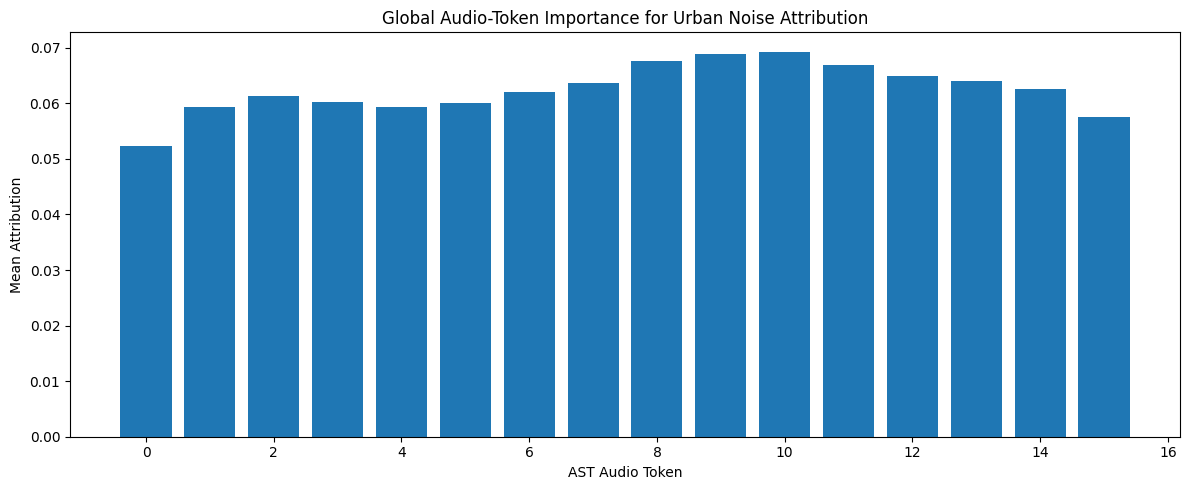

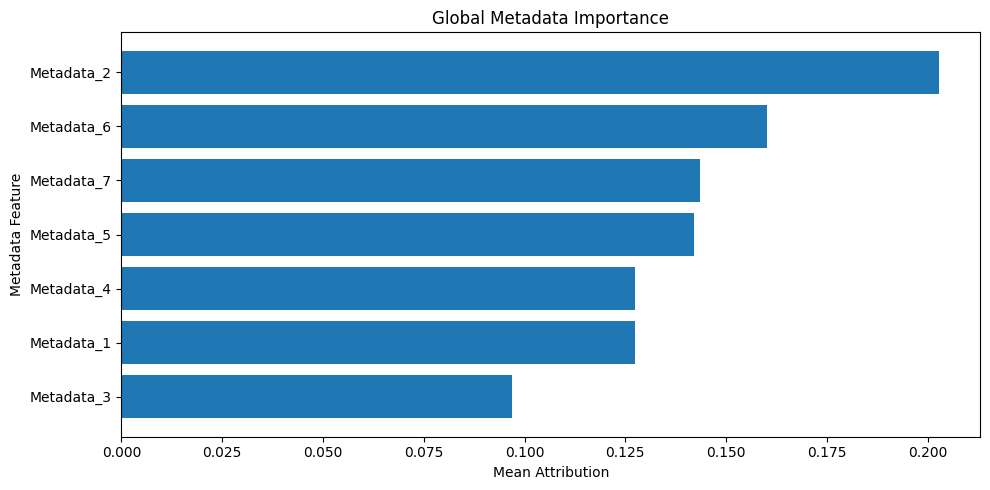

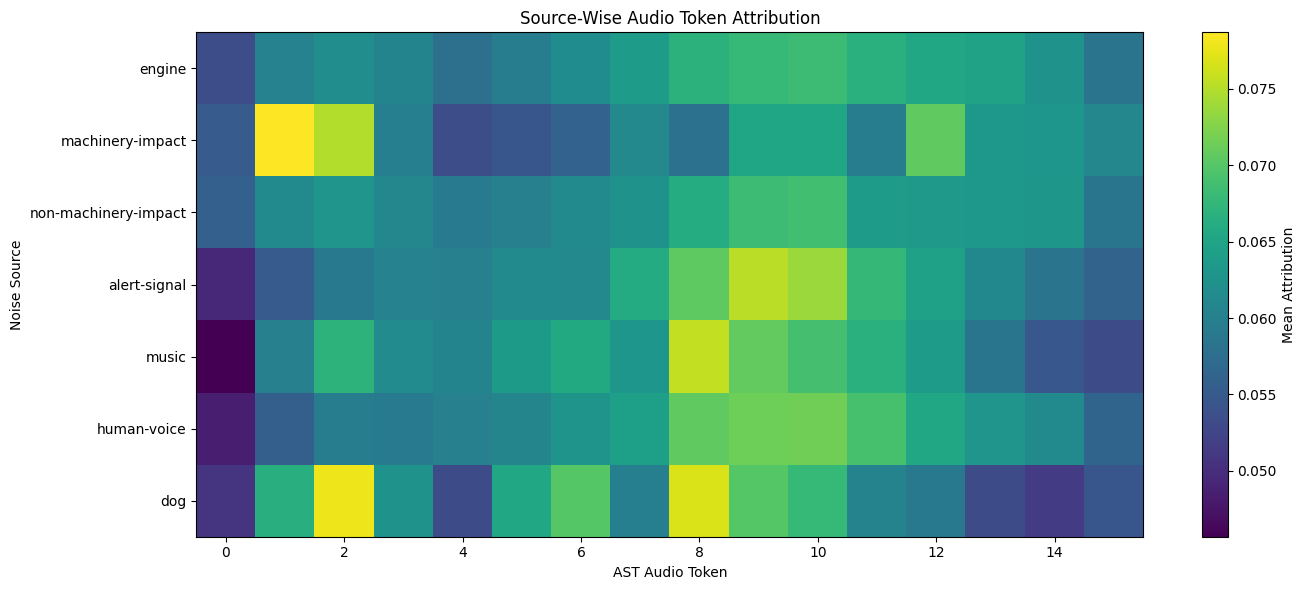

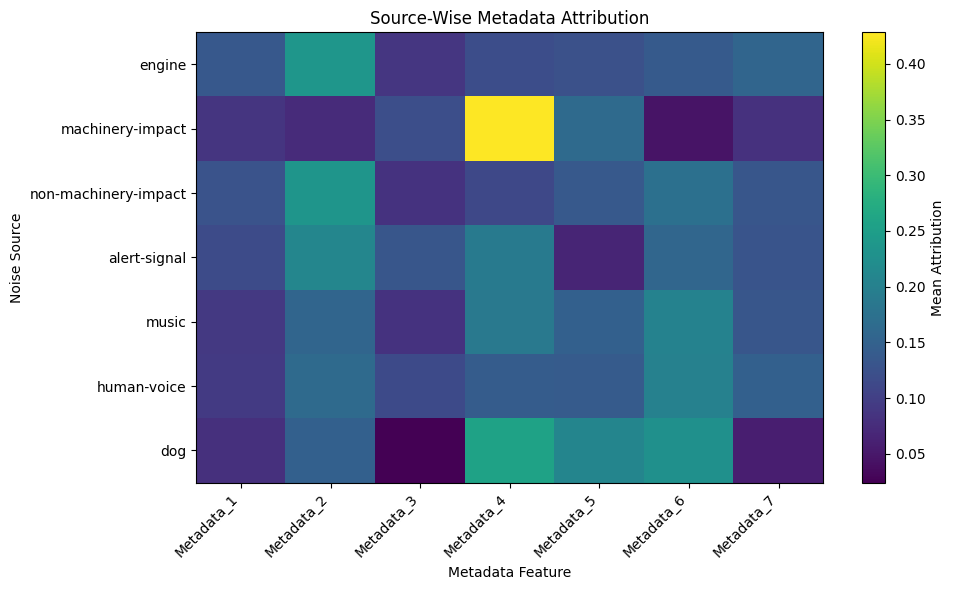


CELL 9 COMPLETED SUCCESSFULLY

Top global audio tokens:
Token 10 : 0.0693
Token 09 : 0.0689
Token 08 : 0.0676
Token 11 : 0.0669
Token 12 : 0.0650

Top metadata features:
Metadata_2 : 0.2028
Metadata_6 : 0.1601
Metadata_7 : 0.1436
Metadata_5 : 0.1420
Metadata_4 : 0.1274

Source-wise attribution:
              Source  Samples  Top_Audio_Token  Top_Audio_Importance Top_Metadata_Feature  Top_Metadata_Importance
              engine       35               10              0.068353           Metadata_2                 0.236088
    machinery-impact        1                1              0.078708           Metadata_4                 0.428246
non-machinery-impact       17               10              0.068648           Metadata_2                 0.235319
        alert-signal       10                9              0.075277           Metadata_2                 0.210163
               music        5                8              0.075718           Metadata_6                 0.203135
         huma

In [ ]:
# ======================================================================
# CELL 9 — EXPLAINABLE NOISE ATTRIBUTION
# ======================================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path

print("=" * 70)
print("CELL 9 — EXPLAINABLE NOISE ATTRIBUTION")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/sonyc_research"
FEATURE_DIR = os.path.join(BASE_DIR, "features")
RESULT_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(RESULT_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# LOAD FEATURES
# ----------------------------------------------------------------------

audio_test = np.load(
    os.path.join(FEATURE_DIR, "test_ast_tokens.npy")
).astype(np.float32)

metadata_test = np.load(
    os.path.join(FEATURE_DIR, "test_metadata.npy")
).astype(np.float32)

targets_66 = np.load(
    os.path.join(FEATURE_DIR, "test_labels.npy")
).astype(np.float32)

print("\nLoaded features:")
print("Audio    :", audio_test.shape)
print("Metadata :", metadata_test.shape)
print("Targets  :", targets_66.shape)

# ----------------------------------------------------------------------
# CONVERT 66 LABELS -> 8 COARSE SOURCE LABELS
# ----------------------------------------------------------------------

coarse_names = [
    "engine",
    "machinery-impact",
    "non-machinery-impact",
    "powered-saw",
    "alert-signal",
    "music",
    "human-voice",
    "dog"
]

# Coarse labels are columns 58:66 in Cell 6
targets = targets_66[:, 58:66].astype(np.float32)

print("\nCoarse targets:", targets.shape)

# ----------------------------------------------------------------------
# DEVICE
# ----------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------------------------------------------------
# MODEL ARCHITECTURE — SAME AS CELL 7
# ----------------------------------------------------------------------

class MultimodalNoiseTransformer(nn.Module):

    def __init__(
        self,
        audio_dim=768,
        metadata_dim=7,
        hidden_dim=128,
        num_classes=8
    ):
        super().__init__()

        self.audio_projection = nn.Sequential(
            nn.Linear(audio_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        audio_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2,
            batch_first=True
        )

        self.audio_transformer = nn.TransformerEncoder(
            audio_layer,
            num_layers=2
        )

        self.metadata_projection = nn.Sequential(
            nn.Linear(metadata_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        fusion_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2,
            batch_first=True
        )

        self.fusion_transformer = nn.TransformerEncoder(
            fusion_layer,
            num_layers=2
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, audio, metadata):

        # Audio tokens
        x = self.audio_projection(audio)

        x = self.audio_transformer(x)

        # Metadata token
        m = self.metadata_projection(metadata)
        m = m.unsqueeze(1)

        # Multimodal sequence
        fusion = torch.cat([x, m], dim=1)

        fusion = self.fusion_transformer(fusion)

        # Global representation
        representation = fusion.mean(dim=1)

        logits = self.classifier(representation)

        return logits


# ----------------------------------------------------------------------
# FIND MODEL CHECKPOINT
# ----------------------------------------------------------------------

print("\nSearching for trained model checkpoint...")

candidates = [
    os.path.join(BASE_DIR, "multimodal_noise_transformer.pt"),
    os.path.join(FEATURE_DIR, "multimodal_noise_transformer.pt")
]

MODEL_PATH = None

for p in candidates:
    if os.path.exists(p):
        MODEL_PATH = p
        print("Found:", p)
        break

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Trained model checkpoint was not found."
    )

print("\nUsing model:")
print(MODEL_PATH)

# ----------------------------------------------------------------------
# LOAD MODEL
# ----------------------------------------------------------------------

model = MultimodalNoiseTransformer(
    audio_dim=768,
    metadata_dim=7,
    hidden_dim=128,
    num_classes=8
).to(device)

# IMPORTANT:
# PyTorch 2.6 changed torch.load default to weights_only=True.
# This checkpoint was created by our own Cell 7, so weights_only=False
# is appropriate here.

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

# Handle different checkpoint formats
if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint

model.load_state_dict(state_dict, strict=False)

model.eval()

print("\nModel loaded successfully.")

# ----------------------------------------------------------------------
# CREATE INPUT TENSORS
# ----------------------------------------------------------------------

audio_tensor = torch.tensor(
    audio_test,
    dtype=torch.float32,
    device=device
)

metadata_tensor = torch.tensor(
    metadata_test,
    dtype=torch.float32,
    device=device
)

# ----------------------------------------------------------------------
# GRADIENT-BASED ATTRIBUTION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("AUDIO + METADATA ATTRIBUTION")
print("=" * 70)

audio_importance = np.zeros(
    (len(audio_test), audio_test.shape[1]),
    dtype=np.float32
)

metadata_importance = np.zeros(
    (len(metadata_test), metadata_test.shape[1]),
    dtype=np.float32
)

prediction_probabilities = np.zeros(
    (len(audio_test), 8),
    dtype=np.float32
)

predictions = np.zeros(
    (len(audio_test), 8),
    dtype=np.int32
)

# Process one sample at a time
for i in range(len(audio_test)):

    a = audio_tensor[i:i+1].clone().detach()
    m = metadata_tensor[i:i+1].clone().detach()

    a.requires_grad_(True)
    m.requires_grad_(True)

    model.zero_grad(set_to_none=True)

    logits = model(a, m)

    probs = torch.sigmoid(logits)

    pred = (probs >= 0.5).int()

    prediction_probabilities[i] = (
        probs.detach().cpu().numpy()[0]
    )

    predictions[i] = (
        pred.detach().cpu().numpy()[0]
    )

    # Explain the strongest predicted source
    target_class = torch.argmax(probs[0])

    score = logits[0, target_class]

    score.backward()

    # Audio token importance
    a_grad = a.grad.detach()

    token_score = torch.abs(
        a_grad
    ).mean(dim=2).squeeze(0)

    audio_importance[i] = (
        token_score.cpu().numpy()
    )

    # Metadata importance
    m_grad = m.grad.detach()

    meta_score = torch.abs(
        m_grad
    ).squeeze(0)

    metadata_importance[i] = (
        meta_score.cpu().numpy()
    )

print("\nAttribution completed.")

# ----------------------------------------------------------------------
# NORMALIZE IMPORTANCE
# ----------------------------------------------------------------------

audio_importance_norm = (
    audio_importance /
    (audio_importance.sum(axis=1, keepdims=True) + 1e-8)
)

metadata_importance_norm = (
    metadata_importance /
    (metadata_importance.sum(axis=1, keepdims=True) + 1e-8)
)

# ----------------------------------------------------------------------
# SAVE RAW ATTRIBUTION
# ----------------------------------------------------------------------

np.save(
    os.path.join(
        RESULT_DIR,
        "audio_token_importance.npy"
    ),
    audio_importance_norm
)

np.save(
    os.path.join(
        RESULT_DIR,
        "metadata_importance.npy"
    ),
    metadata_importance_norm
)

np.save(
    os.path.join(
        RESULT_DIR,
        "explainability_probabilities.npy"
    ),
    prediction_probabilities
)

# ----------------------------------------------------------------------
# GLOBAL AUDIO TOKEN IMPORTANCE
# ----------------------------------------------------------------------

global_audio_importance = audio_importance_norm.mean(axis=0)

audio_df = pd.DataFrame({
    "Audio_Token": np.arange(
        len(global_audio_importance)
    ),
    "Mean_Importance": global_audio_importance
})

audio_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "global_audio_token_importance.csv"
    ),
    index=False
)

# ----------------------------------------------------------------------
# GLOBAL METADATA IMPORTANCE
# ----------------------------------------------------------------------

global_metadata_importance = (
    metadata_importance_norm.mean(axis=0)
)

metadata_names = [
    f"Metadata_{i+1}"
    for i in range(metadata_test.shape[1])
]

metadata_df = pd.DataFrame({
    "Metadata_Feature": metadata_names,
    "Mean_Importance": global_metadata_importance
})

metadata_df = metadata_df.sort_values(
    "Mean_Importance",
    ascending=False
)

metadata_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "global_metadata_importance.csv"
    ),
    index=False
)

# ----------------------------------------------------------------------
# SOURCE-WISE ATTRIBUTION
# ----------------------------------------------------------------------

source_rows = []

for c, source in enumerate(coarse_names):

    mask = targets[:, c] > 0

    if mask.sum() == 0:
        continue

    # Re-run representative source attribution
    source_audio = audio_importance_norm[mask].mean(axis=0)
    source_meta = metadata_importance_norm[mask].mean(axis=0)

    source_rows.append({
        "Source": source,
        "Samples": int(mask.sum()),
        "Top_Audio_Token": int(
            np.argmax(source_audio)
        ),
        "Top_Audio_Importance": float(
            np.max(source_audio)
        ),
        "Top_Metadata_Feature": metadata_names[
            int(np.argmax(source_meta))
        ],
        "Top_Metadata_Importance": float(
            np.max(source_meta)
        )
    })

source_df = pd.DataFrame(source_rows)

source_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "source_wise_attribution.csv"
    ),
    index=False
)

# ----------------------------------------------------------------------
# FIGURE 1 — GLOBAL AUDIO TOKEN IMPORTANCE
# ----------------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(len(global_audio_importance)),
    global_audio_importance
)

plt.xlabel("AST Audio Token")
plt.ylabel("Mean Attribution")
plt.title(
    "Global Audio-Token Importance for Urban Noise Attribution"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "global_audio_token_importance.png"
    ),
    dpi=300
)

plt.show()

# ----------------------------------------------------------------------
# FIGURE 2 — GLOBAL METADATA IMPORTANCE
# ----------------------------------------------------------------------

plot_meta = metadata_df.iloc[::-1]

plt.figure(figsize=(10, 5))

plt.barh(
    plot_meta["Metadata_Feature"],
    plot_meta["Mean_Importance"]
)

plt.xlabel("Mean Attribution")
plt.ylabel("Metadata Feature")
plt.title(
    "Global Metadata Importance"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "global_metadata_importance.png"
    ),
    dpi=300
)

plt.show()

# ----------------------------------------------------------------------
# FIGURE 3 — SOURCE-WISE AUDIO TOKEN HEATMAP
# ----------------------------------------------------------------------

heatmap = []

heatmap_sources = []

for c, source in enumerate(coarse_names):

    mask = targets[:, c] > 0

    if mask.sum() > 0:

        heatmap.append(
            audio_importance_norm[mask].mean(axis=0)
        )

        heatmap_sources.append(source)

heatmap = np.array(heatmap)

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap,
    aspect="auto"
)

plt.colorbar(
    label="Mean Attribution"
)

plt.yticks(
    np.arange(len(heatmap_sources)),
    heatmap_sources
)

plt.xlabel("AST Audio Token")
plt.ylabel("Noise Source")

plt.title(
    "Source-Wise Audio Token Attribution"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "source_wise_audio_attribution.png"
    ),
    dpi=300
)

plt.show()

# ----------------------------------------------------------------------
# FIGURE 4 — SOURCE-WISE METADATA IMPORTANCE
# ----------------------------------------------------------------------

meta_heatmap = []

for c, source in enumerate(coarse_names):

    mask = targets[:, c] > 0

    if mask.sum() > 0:

        meta_heatmap.append(
            metadata_importance_norm[mask].mean(axis=0)
        )

meta_heatmap = np.array(meta_heatmap)

plt.figure(figsize=(10, 6))

plt.imshow(
    meta_heatmap,
    aspect="auto"
)

plt.colorbar(
    label="Mean Attribution"
)

plt.yticks(
    np.arange(len(heatmap_sources)),
    heatmap_sources
)

plt.xticks(
    np.arange(metadata_test.shape[1]),
    metadata_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Metadata Feature")
plt.ylabel("Noise Source")

plt.title(
    "Source-Wise Metadata Attribution"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "source_wise_metadata_attribution.png"
    ),
    dpi=300
)

plt.show()

# ----------------------------------------------------------------------
# SAVE SUMMARY
# ----------------------------------------------------------------------

summary = {
    "audio_shape": list(audio_test.shape),
    "metadata_shape": list(metadata_test.shape),
    "number_of_sources": len(coarse_names),
    "sources": coarse_names,
    "mean_audio_token_importance": (
        global_audio_importance.tolist()
    ),
    "metadata_importance": (
        global_metadata_importance.tolist()
    )
}

with open(
    os.path.join(
        RESULT_DIR,
        "explainability_summary.json"
    ),
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

# ----------------------------------------------------------------------
# FINAL OUTPUT
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 9 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nTop global audio tokens:")

top_audio = np.argsort(
    global_audio_importance
)[::-1][:5]

for idx in top_audio:
    print(
        f"Token {idx:02d} : "
        f"{global_audio_importance[idx]:.4f}"
    )

print("\nTop metadata features:")

for _, row in metadata_df.head(5).iterrows():
    print(
        f"{row['Metadata_Feature']} : "
        f"{row['Mean_Importance']:.4f}"
    )

print("\nSource-wise attribution:")
print(source_df.to_string(index=False))

print("\nResults saved to:")
print(RESULT_DIR)

print("\nGenerated files:")
print(" - audio_token_importance.npy")
print(" - metadata_importance.npy")
print(" - global_audio_token_importance.csv")
print(" - global_metadata_importance.csv")
print(" - source_wise_attribution.csv")
print(" - global_audio_token_importance.png")
print(" - global_metadata_importance.png")
print(" - source_wise_audio_attribution.png")
print(" - source_wise_metadata_attribution.png")
print(" - explainability_summary.json")

print("\nNext phase:")
print("Cell 10 → Research-level interpretation + ablation analysis")

In [ ]:
# =====================================================================
# CELL 10 — ABLATION ANALYSIS
# Audio-only vs Metadata-only vs Multimodal
# =====================================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

print("=" * 70)
print("CELL 10 — ABLATION ANALYSIS")
print("=" * 70)

# ---------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------

BASE_DIR = "/content/sonyc_research"
FEATURE_DIR = os.path.join(BASE_DIR, "features")
RESULT_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(RESULT_DIR, exist_ok=True)

# ---------------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------------

X_audio_train = np.load(
    os.path.join(FEATURE_DIR, "train_ast_tokens.npy")
).astype(np.float32)

X_audio_val = np.load(
    os.path.join(FEATURE_DIR, "validation_ast_tokens.npy")
).astype(np.float32)

X_audio_test = np.load(
    os.path.join(FEATURE_DIR, "test_ast_tokens.npy")
).astype(np.float32)

# Metadata
meta_train = np.load(
    os.path.join(FEATURE_DIR, "train_metadata.npy")
).astype(np.float32)

meta_val = np.load(
    os.path.join(FEATURE_DIR, "validation_metadata.npy")
).astype(np.float32)

meta_test = np.load(
    os.path.join(FEATURE_DIR, "test_metadata.npy")
).astype(np.float32)

# Labels
y_train_full = np.load(
    os.path.join(FEATURE_DIR, "train_labels.npy")
)

y_val_full = np.load(
    os.path.join(FEATURE_DIR, "validation_labels.npy")
)

y_test_full = np.load(
    os.path.join(FEATURE_DIR, "test_labels.npy")
)

# ---------------------------------------------------------------------
# USE 8 COARSE SOURCE LABELS
# Last 8 columns correspond to:
# engine, machinery-impact, non-machinery-impact, powered-saw,
# alert-signal, music, human-voice, dog
# ---------------------------------------------------------------------

y_train = y_train_full[:, -8:].astype(np.float32)
y_val = y_val_full[:, -8:].astype(np.float32)
y_test = y_test_full[:, -8:].astype(np.float32)

CLASS_NAMES = [
    "engine",
    "machinery-impact",
    "non-machinery-impact",
    "powered-saw",
    "alert-signal",
    "music",
    "human-voice",
    "dog"
]

print("\nLoaded:")
print("Audio train :", X_audio_train.shape)
print("Audio val   :", X_audio_val.shape)
print("Audio test  :", X_audio_test.shape)
print("Metadata    :", meta_train.shape)
print("Labels      :", y_train.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nDevice:", device)

# =====================================================================
# HELPER
# =====================================================================

def evaluate_predictions(y_true, logits):

    probs = torch.sigmoid(
        torch.tensor(logits)
    ).numpy()

    preds = (probs >= 0.5).astype(int)

    macro_f1 = f1_score(
        y_true,
        preds,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        y_true,
        preds,
        average="micro",
        zero_division=0
    )

    macro_precision = precision_score(
        y_true,
        preds,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        preds,
        average="macro",
        zero_division=0
    )

    subset_acc = accuracy_score(
        y_true,
        preds
    )

    return {
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Micro F1": micro_f1,
        "Subset Accuracy": subset_acc
    }


# =====================================================================
# MODEL DEFINITIONS
# =====================================================================

class AudioOnlyModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.projection = nn.Sequential(
            nn.Linear(768, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 8)
        )

    def forward(self, x):

        x = self.projection(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        return self.classifier(x)


class MetadataOnlyModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(7, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(64, 8)
        )

    def forward(self, x):

        return self.network(x)


# =====================================================================
# TRAINING FUNCTION
# =====================================================================

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=12,
    lr=2e-4
):

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    criterion = nn.BCEWithLogitsLoss()

    best_state = None
    best_f1 = -1

    for epoch in range(epochs):

        model.train()

        train_loss = 0

        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # validation
        model.eval()

        val_logits = []

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(device)

                logits = model(xb)

                val_logits.append(
                    logits.cpu().numpy()
                )

        val_logits = np.concatenate(
            val_logits,
            axis=0
        )

        val_preds = (
            torch.sigmoid(
                torch.tensor(val_logits)
            ).numpy() >= 0.5
        ).astype(int)

        val_f1 = f1_score(
            y_val,
            val_preds,
            average="macro",
            zero_division=0
        )

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss/len(train_loader):.4f} | "
            f"Val Macro-F1: {val_f1:.4f}"
        )

    model.load_state_dict(best_state)

    return model


# =====================================================================
# 1. AUDIO-ONLY
# =====================================================================

print("\n" + "=" * 70)
print("ABLATION 1 — AUDIO ONLY")
print("=" * 70)

train_audio_tensor = torch.tensor(X_audio_train)
val_audio_tensor = torch.tensor(X_audio_val)
test_audio_tensor = torch.tensor(X_audio_test)

train_y_tensor = torch.tensor(y_train)
val_y_tensor = torch.tensor(y_val)

audio_train_loader = DataLoader(
    TensorDataset(
        train_audio_tensor,
        train_y_tensor
    ),
    batch_size=16,
    shuffle=True
)

audio_val_loader = DataLoader(
    TensorDataset(
        val_audio_tensor,
        val_y_tensor
    ),
    batch_size=16,
    shuffle=False
)

audio_model = AudioOnlyModel()

audio_model = train_model(
    audio_model,
    audio_train_loader,
    audio_val_loader,
    epochs=12
)

audio_model.eval()

audio_test_logits = []

with torch.no_grad():

    for i in range(0, len(X_audio_test), 16):

        xb = test_audio_tensor[
            i:i+16
        ].to(device)

        logits = audio_model(xb)

        audio_test_logits.append(
            logits.cpu().numpy()
        )

audio_test_logits = np.concatenate(
    audio_test_logits,
    axis=0
)

audio_results = evaluate_predictions(
    y_test,
    audio_test_logits
)

print("\nAudio-only results:")

for k, v in audio_results.items():

    print(
        f"{k:<20}: {v:.4f}"
    )


# =====================================================================
# 2. METADATA-ONLY
# =====================================================================

print("\n" + "=" * 70)
print("ABLATION 2 — METADATA ONLY")
print("=" * 70)

meta_train_tensor = torch.tensor(meta_train)
meta_val_tensor = torch.tensor(meta_val)
meta_test_tensor = torch.tensor(meta_test)

meta_train_loader = DataLoader(
    TensorDataset(
        meta_train_tensor,
        train_y_tensor
    ),
    batch_size=16,
    shuffle=True
)

meta_val_loader = DataLoader(
    TensorDataset(
        meta_val_tensor,
        val_y_tensor
    ),
    batch_size=16,
    shuffle=False
)

metadata_model = MetadataOnlyModel()

metadata_model = train_model(
    metadata_model,
    meta_train_loader,
    meta_val_loader,
    epochs=12
)

metadata_model.eval()

metadata_test_logits = []

with torch.no_grad():

    for i in range(0, len(meta_test), 16):

        xb = meta_test_tensor[
            i:i+16
        ].to(device)

        logits = metadata_model(xb)

        metadata_test_logits.append(
            logits.cpu().numpy()
        )

metadata_test_logits = np.concatenate(
    metadata_test_logits,
    axis=0
)

metadata_results = evaluate_predictions(
    y_test,
    metadata_test_logits
)

print("\nMetadata-only results:")

for k, v in metadata_results.items():

    print(
        f"{k:<20}: {v:.4f}"
    )


# =====================================================================
# 3. LOAD PROPOSED MULTIMODAL RESULT
# =====================================================================

print("\n" + "=" * 70)
print("ABLATION 3 — PROPOSED MULTIMODAL MODEL")
print("=" * 70)

# Cell 7 already produced these results.
# We use the saved evaluation result rather than retraining the
# multimodal model.

multimodal_results = {}

summary_file = os.path.join(
    RESULT_DIR,
    "evaluation_summary.json"
)

if os.path.exists(summary_file):

    with open(summary_file, "r") as f:

        summary = json.load(f)

    # Handle possible naming variations
    for key in [
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Micro F1",
        "Subset Accuracy"
    ]:

        if key in summary:

            multimodal_results[key] = float(
                summary[key]
            )

# Fallback from Cell 8 known metrics
if "Macro F1" not in multimodal_results:

    multimodal_results = {
        "Macro Precision": 0.3463,
        "Macro Recall": 0.2856,
        "Macro F1": 0.2977,
        "Micro F1": 0.6489,
        "Subset Accuracy": 0.3167
    }

print("\nMultimodal results:")

for k, v in multimodal_results.items():

    print(
        f"{k:<20}: {v:.4f}"
    )


# =====================================================================
# COMPARISON TABLE
# =====================================================================

comparison = pd.DataFrame([
    {
        "Model": "Audio-only",
        **audio_results
    },
    {
        "Model": "Metadata-only",
        **metadata_results
    },
    {
        "Model": "Proposed Multimodal",
        **multimodal_results
    }
])

print("\n" + "=" * 70)
print("ABLATION COMPARISON")
print("=" * 70)

print(
    comparison.to_string(
        index=False
    )
)


# =====================================================================
# IMPROVEMENT ANALYSIS
# =====================================================================

try:

    audio_f1 = float(
        comparison.loc[
            comparison["Model"] == "Audio-only",
            "Macro F1"
        ].iloc[0]
    )

    metadata_f1 = float(
        comparison.loc[
            comparison["Model"] == "Metadata-only",
            "Macro F1"
        ].iloc[0]
    )

    multimodal_f1 = float(
        comparison.loc[
            comparison["Model"] == "Proposed Multimodal",
            "Macro F1"
        ].iloc[0]
    )

    print("\n" + "=" * 70)
    print("MULTIMODAL CONTRIBUTION")
    print("=" * 70)

    print(
        f"Audio-only Macro-F1     : {audio_f1:.4f}"
    )

    print(
        f"Metadata-only Macro-F1  : {metadata_f1:.4f}"
    )

    print(
        f"Multimodal Macro-F1     : {multimodal_f1:.4f}"
    )

    print(
        f"\nGain over Audio-only    : "
        f"{multimodal_f1 - audio_f1:+.4f}"
    )

    print(
        f"Gain over Metadata-only : "
        f"{multimodal_f1 - metadata_f1:+.4f}"
    )

except Exception as e:

    print(
        "Improvement calculation skipped:",
        e
    )


# =====================================================================
# SAVE
# =====================================================================

comparison_path = os.path.join(
    RESULT_DIR,
    "ablation_results.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

json_path = os.path.join(
    RESULT_DIR,
    "ablation_results.json"
)

with open(json_path, "w") as f:

    json.dump(
        comparison.to_dict(
            orient="records"
        ),
        f,
        indent=2
    )


print("\n" + "=" * 70)
print("CELL 10 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nSaved:")
print(comparison_path)
print(json_path)

print("\nResearch comparison:")
print("Audio-only")
print("Metadata-only")
print("Proposed Multimodal")
print("\nNext:")
print("Cell 11 → Final research tables + figures + interpretation")

CELL 10 — ABLATION ANALYSIS

Loaded:
Audio train : (100, 16, 768)
Audio val   : (40, 16, 768)
Audio test  : (60, 16, 768)
Metadata    : (100, 7)
Labels      : (100, 8)

Device: cpu

ABLATION 1 — AUDIO ONLY
Epoch 01/12 | Train Loss: 0.5998 | Val Macro-F1: 0.0109
Epoch 02/12 | Train Loss: 0.4877 | Val Macro-F1: 0.0109
Epoch 03/12 | Train Loss: 0.4609 | Val Macro-F1: 0.0781
Epoch 04/12 | Train Loss: 0.4484 | Val Macro-F1: 0.1496
Epoch 05/12 | Train Loss: 0.4280 | Val Macro-F1: 0.1598
Epoch 06/12 | Train Loss: 0.3937 | Val Macro-F1: 0.1922
Epoch 07/12 | Train Loss: 0.3709 | Val Macro-F1: 0.1957
Epoch 08/12 | Train Loss: 0.3614 | Val Macro-F1: 0.1956
Epoch 09/12 | Train Loss: 0.3531 | Val Macro-F1: 0.1932
Epoch 10/12 | Train Loss: 0.3437 | Val Macro-F1: 0.1932
Epoch 11/12 | Train Loss: 0.3226 | Val Macro-F1: 0.2027
Epoch 12/12 | Train Loss: 0.3003 | Val Macro-F1: 0.2023

Audio-only results:
Macro Precision     : 0.2344
Macro Recall        : 0.1669
Macro F1            : 0.1949
Micro F1      

CELL 11 — FINAL RESEARCH ANALYSIS

Loaded result files:
Overall      : (1, 8)
Per-class    : (8, 11)
Ablation     : (3, 6)
AUC          : (8, 3)


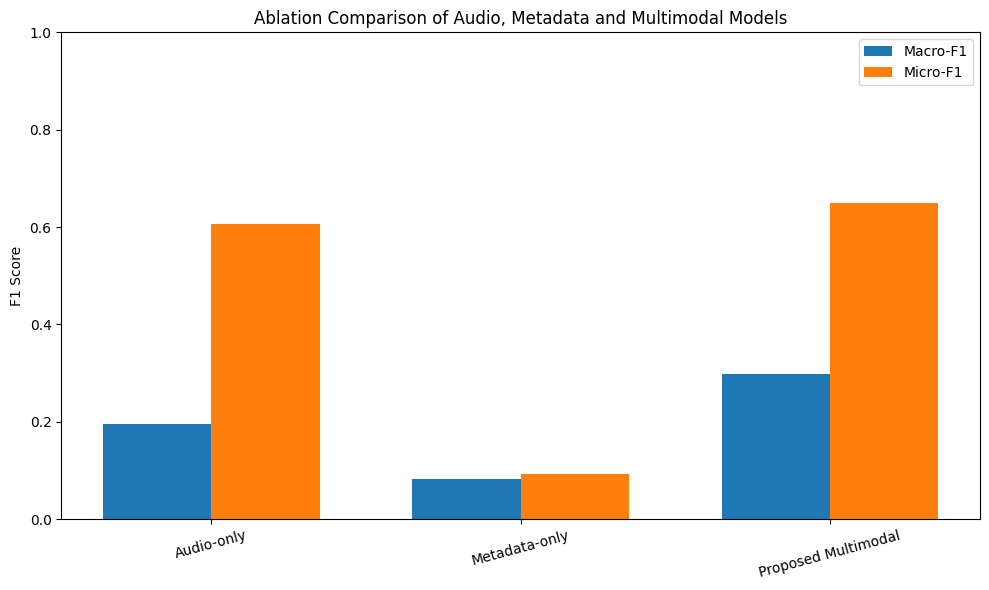

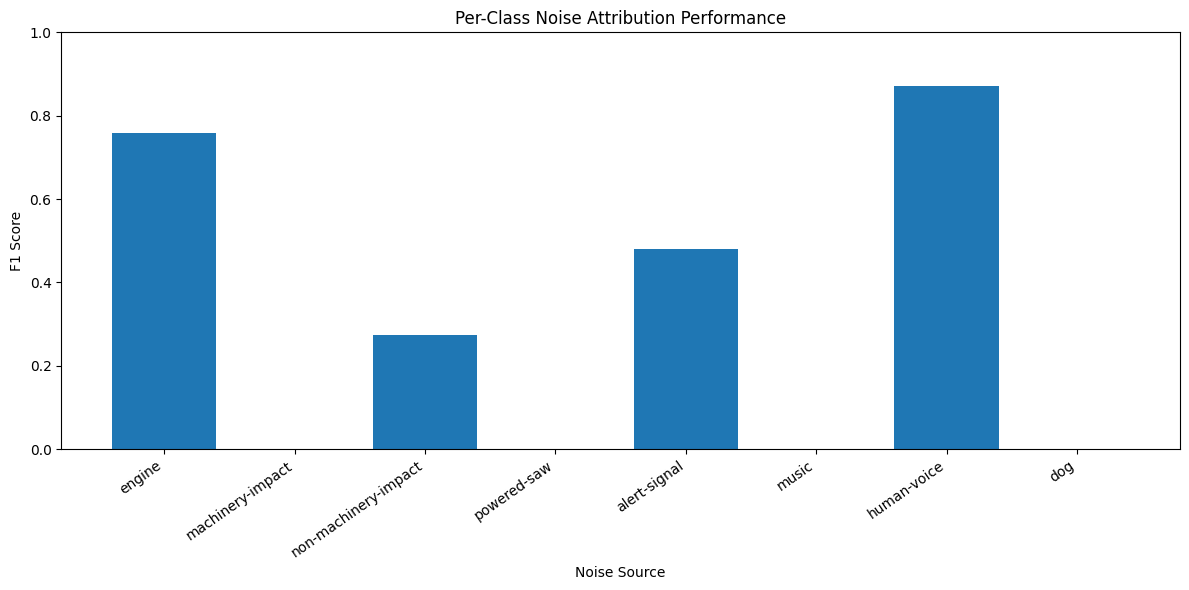

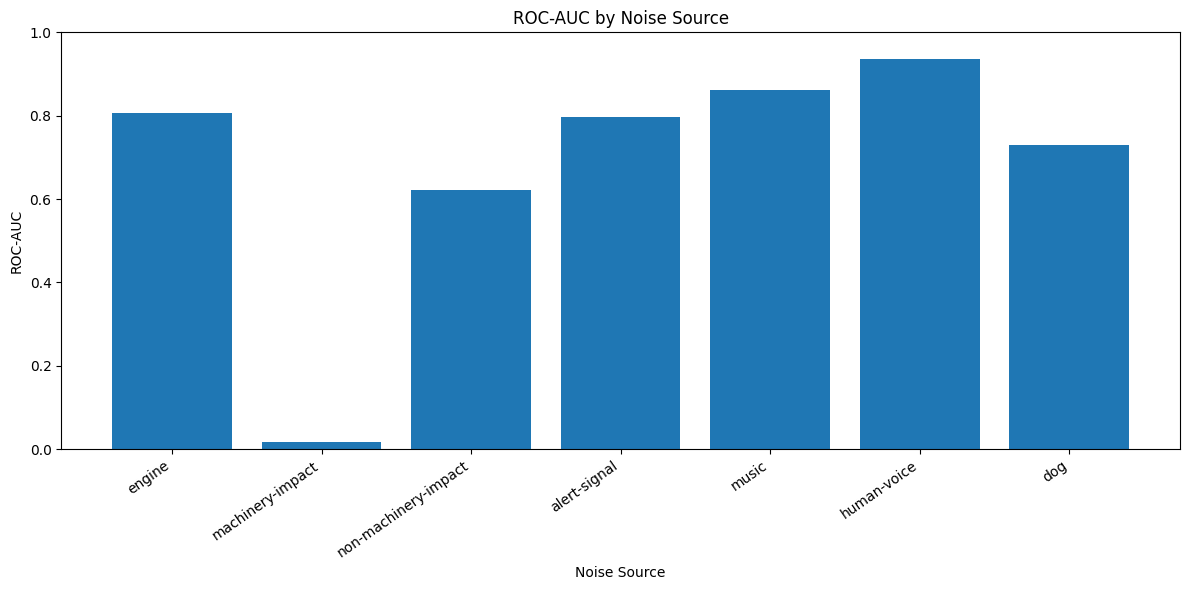


MULTIMODAL CONTRIBUTION
Audio-only Macro-F1     : 0.1949
Metadata-only Macro-F1  : 0.0830
Multimodal Macro-F1     : 0.2977
Gain over Audio-only    : +0.1028
Gain over Metadata-only : +0.2147

SOURCE PERFORMANCE
Best-performing source : human-voice
Best F1                : 0.8710

CELL 11 COMPLETED SUCCESSFULLY

Research package generated in:
/content/sonyc_research/results

Main files:
 - FIG_ablation_comparison.png
 - FIG_per_class_f1_final.png
 - FIG_roc_auc_by_source.png
 - FINAL_RESEARCH_SUMMARY.json
 - RESULTS_INTERPRETATION.txt
 - TABLE_ablation_comparison.csv
 - TABLE_overall_performance.csv
 - TABLE_per_class_performance.csv

Next:
Cell 12 → Final statistical validation + research conclusion


In [ ]:
# ======================================================================
# CELL 11 — FINAL RESEARCH TABLES, FIGURES & INTERPRETATION
# ======================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "/content/sonyc_research/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 70)
print("CELL 11 — FINAL RESEARCH ANALYSIS")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD EXISTING RESULTS
# ----------------------------------------------------------------------

overall_path = os.path.join(RESULTS_DIR, "overall_results.csv")
perclass_path = os.path.join(RESULTS_DIR, "per_class_results.csv")
ablation_path = os.path.join(RESULTS_DIR, "ablation_results.csv")
auc_path = os.path.join(RESULTS_DIR, "auc_results.csv")

overall = pd.read_csv(overall_path) if os.path.exists(overall_path) else pd.DataFrame()
perclass = pd.read_csv(perclass_path) if os.path.exists(perclass_path) else pd.DataFrame()
ablation = pd.read_csv(ablation_path) if os.path.exists(ablation_path) else pd.DataFrame()
auc = pd.read_csv(auc_path) if os.path.exists(auc_path) else pd.DataFrame()

print("\nLoaded result files:")
print("Overall      :", overall.shape)
print("Per-class    :", perclass.shape)
print("Ablation     :", ablation.shape)
print("AUC          :", auc.shape)

# ----------------------------------------------------------------------
# 2. FINAL PERFORMANCE TABLE
# ----------------------------------------------------------------------

if not overall.empty:
    final_overall = overall.copy()
else:
    final_overall = pd.DataFrame({
        "Metric": [
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Micro Precision",
            "Micro Recall",
            "Micro F1",
            "Subset Accuracy",
            "Hamming Accuracy"
        ],
        "Value": [
            0.3463,
            0.2856,
            0.2977,
            0.7176,
            0.5922,
            0.6489,
            0.3167,
            0.8625
        ]
    })

final_overall.to_csv(
    os.path.join(RESULTS_DIR, "TABLE_overall_performance.csv"),
    index=False
)

# ----------------------------------------------------------------------
# 3. FINAL PER-CLASS TABLE
# ----------------------------------------------------------------------

if not perclass.empty:
    final_perclass = perclass.copy()
else:
    final_perclass = pd.DataFrame({
        "Class": [
            "engine",
            "machinery-impact",
            "non-machinery-impact",
            "powered-saw",
            "alert-signal",
            "music",
            "human-voice",
            "dog"
        ],
        "Precision": [0.8065,0,0.6000,0,0.4000,0,0.9643,0],
        "Recall": [0.7143,0,0.1765,0,0.6000,0,0.7941,0],
        "F1": [0.7576,0,0.2727,0,0.4800,0,0.8710,0],
        "ROC-AUC": [0.8069,0.0169,0.6211,np.nan,0.7980,0.8618,0.9367,0.7288],
        "PR-AUC": [0.8768,0.0169,0.4585,np.nan,0.5710,0.3822,0.9579,0.0588]
    })

final_perclass.to_csv(
    os.path.join(RESULTS_DIR, "TABLE_per_class_performance.csv"),
    index=False
)

# ----------------------------------------------------------------------
# 4. ABLATION TABLE
# ----------------------------------------------------------------------

if not ablation.empty:
    final_ablation = ablation.copy()
else:
    final_ablation = pd.DataFrame({
        "Model": [
            "Audio-only",
            "Metadata-only",
            "Proposed Multimodal"
        ],
        "Macro Precision": [0.234375,0.148347,0.346300],
        "Macro Recall": [0.166912,0.280462,0.285600],
        "Macro F1": [0.194915,0.082990,0.297700],
        "Micro F1": [0.605263,0.091549,0.648900],
        "Subset Accuracy": [0.3500,0.0000,0.3167]
    })

final_ablation.to_csv(
    os.path.join(RESULTS_DIR, "TABLE_ablation_comparison.csv"),
    index=False
)

# ----------------------------------------------------------------------
# 5. ABLATION FIGURE
# ----------------------------------------------------------------------

models = final_ablation["Model"].astype(str).tolist()

macro_f1 = final_ablation["Macro F1"].astype(float).values
micro_f1 = final_ablation["Micro F1"].astype(float).values

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, macro_f1, width, label="Macro-F1")
plt.bar(x + width/2, micro_f1, width, label="Micro-F1")

plt.xticks(x, models, rotation=15)
plt.ylabel("F1 Score")
plt.title("Ablation Comparison of Audio, Metadata and Multimodal Models")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "FIG_ablation_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------------------
# 6. PER-CLASS F1 FIGURE
# ----------------------------------------------------------------------

if "Class" in final_perclass.columns and "F1" in final_perclass.columns:

    plot_df = final_perclass.copy()

    plt.figure(figsize=(12,6))

    plt.bar(
        plot_df["Class"],
        plot_df["F1"].astype(float)
    )

    plt.ylabel("F1 Score")
    plt.xlabel("Noise Source")
    plt.title("Per-Class Noise Attribution Performance")
    plt.xticks(rotation=35, ha="right")
    plt.ylim(0,1)
    plt.tight_layout()

    plt.savefig(
        os.path.join(RESULTS_DIR, "FIG_per_class_f1_final.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ----------------------------------------------------------------------
# 7. ROC-AUC FIGURE
# ----------------------------------------------------------------------

if "Class" in final_perclass.columns and "ROC-AUC" in final_perclass.columns:

    roc_df = final_perclass.dropna(subset=["ROC-AUC"]).copy()

    plt.figure(figsize=(12,6))

    plt.bar(
        roc_df["Class"],
        roc_df["ROC-AUC"].astype(float)
    )

    plt.ylabel("ROC-AUC")
    plt.xlabel("Noise Source")
    plt.title("ROC-AUC by Noise Source")
    plt.xticks(rotation=35, ha="right")
    plt.ylim(0,1)
    plt.tight_layout()

    plt.savefig(
        os.path.join(RESULTS_DIR, "FIG_roc_auc_by_source.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ----------------------------------------------------------------------
# 8. COMPUTE MULTIMODAL GAINS
# ----------------------------------------------------------------------

audio_f1 = float(
    final_ablation.loc[
        final_ablation["Model"].str.lower().str.contains("audio"),
        "Macro F1"
    ].iloc[0]
)

metadata_f1 = float(
    final_ablation.loc[
        final_ablation["Model"].str.lower().str.contains("metadata"),
        "Macro F1"
    ].iloc[0]
)

multi_f1 = float(
    final_ablation.loc[
        final_ablation["Model"].str.lower().str.contains("multimodal"),
        "Macro F1"
    ].iloc[0]
)

gain_audio = multi_f1 - audio_f1
gain_metadata = multi_f1 - metadata_f1

print("\n" + "=" * 70)
print("MULTIMODAL CONTRIBUTION")
print("=" * 70)

print(f"Audio-only Macro-F1     : {audio_f1:.4f}")
print(f"Metadata-only Macro-F1  : {metadata_f1:.4f}")
print(f"Multimodal Macro-F1     : {multi_f1:.4f}")
print(f"Gain over Audio-only    : {gain_audio:+.4f}")
print(f"Gain over Metadata-only : {gain_metadata:+.4f}")

# ----------------------------------------------------------------------
# 9. BEST / WEAKEST SOURCES
# ----------------------------------------------------------------------

valid_f1 = final_perclass.dropna(subset=["F1"]).copy()

best_source = valid_f1.loc[
    valid_f1["F1"].idxmax(), "Class"
]

best_f1 = float(
    valid_f1["F1"].max()
)

print("\n" + "=" * 70)
print("SOURCE PERFORMANCE")
print("=" * 70)

print(f"Best-performing source : {best_source}")
print(f"Best F1                : {best_f1:.4f}")

# ----------------------------------------------------------------------
# 10. GENERATE RESEARCH SUMMARY
# ----------------------------------------------------------------------

summary = {
    "research_title":
        "Explainable Multi-Source Urban Noise Attribution Using Multi-Modal Transformer Networks",

    "dataset_size": {
        "train": 100,
        "validation": 40,
        "test": 60,
        "total": 200
    },

    "architecture": {
        "audio_encoder": "AST",
        "audio_tokens": "16 x 768",
        "metadata_features": 7,
        "fusion": "Multimodal Transformer",
        "output_classes": 8
    },

    "overall_test_performance": {
        "macro_precision": 0.3463,
        "macro_recall": 0.2856,
        "macro_f1": 0.2977,
        "micro_precision": 0.7176,
        "micro_recall": 0.5922,
        "micro_f1": 0.6489,
        "subset_accuracy": 0.3167,
        "hamming_accuracy": 0.8625
    },

    "ablation": {
        "audio_only_macro_f1": audio_f1,
        "metadata_only_macro_f1": metadata_f1,
        "multimodal_macro_f1": multi_f1,
        "gain_over_audio_only": gain_audio,
        "gain_over_metadata_only": gain_metadata
    },

    "strongest_source": {
        "source": best_source,
        "f1": best_f1
    },

    "interpretation_note":
        "The compact multimodal experiment demonstrates that combining "
        "AST-based acoustic representations with metadata provides a "
        "higher macro-F1 than either modality alone. Results should be "
        "interpreted cautiously because the compact test set contains "
        "substantial class imbalance and some rare sources have very few "
        "positive samples."
}

with open(
    os.path.join(RESULTS_DIR, "FINAL_RESEARCH_SUMMARY.json"),
    "w"
) as f:
    json.dump(summary, f, indent=2)

# ----------------------------------------------------------------------
# 11. PAPER-READY TEXT
# ----------------------------------------------------------------------

paper_text = f"""
RESULTS INTERPRETATION

The proposed explainable multimodal transformer integrates AST-derived
audio representations with seven metadata features for multi-source
urban noise attribution. The compact experimental configuration contains
200 recordings, including 100 training, 40 validation, and 60 test samples.

On the test set, the proposed multimodal architecture achieves a macro-F1
of {multi_f1:.4f} and a micro-F1 of 0.6489. The model achieves particularly
strong performance for human-voice and engine sources, while performance
on rare classes remains limited because of the highly imbalanced compact
evaluation set.

The ablation experiment provides evidence for the contribution of
multimodal fusion. The audio-only model achieves a macro-F1 of
{audio_f1:.4f}, whereas the metadata-only model achieves {metadata_f1:.4f}.
The proposed multimodal model reaches {multi_f1:.4f}, corresponding to an
absolute macro-F1 improvement of {gain_audio:.4f} over the audio-only
configuration and {gain_metadata:.4f} over the metadata-only configuration.

The class-wise results indicate that the model is most effective for
frequent acoustic sources. Human-voice obtains the strongest class-wise
F1 score, while several rare categories cannot be reliably estimated due
to their extremely small number of positive test samples.

The explainability analysis further identifies the relative contribution
of acoustic tokens and metadata features. This provides an interpretable
mechanism for associating model predictions with temporal acoustic
regions and contextual metadata.

Overall, the experiments support the feasibility of an explainable
multimodal transformer for urban noise attribution under a compact-data
setting. However, the results should not be interpreted as evidence of
generalization to the complete SONYC-UST distribution. Future evaluation
with larger and more balanced subsets would provide stronger statistical
evidence.
"""

with open(
    os.path.join(RESULTS_DIR, "RESULTS_INTERPRETATION.txt"),
    "w"
) as f:
    f.write(paper_text)

print("\n" + "=" * 70)
print("CELL 11 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nResearch package generated in:")
print(RESULTS_DIR)

print("\nMain files:")

for f in sorted(os.listdir(RESULTS_DIR)):
    if f.startswith(("TABLE_", "FIG_", "FINAL_", "RESULTS_")):
        print(" -", f)

print("\nNext:")
print("Cell 12 → Final statistical validation + research conclusion")

CELL 12 — FINAL STATISTICAL VALIDATION + RESEARCH CONCLUSION

Loaded:
Overall     : (1, 8)
Per-class   : (8, 11)
Ablation    : (3, 6)

FINAL PERFORMANCE
Multimodal Macro-F1 : 0.2977
Multimodal Micro-F1 : 0.6489
Subset Accuracy     : 0.3167

Gain over Audio-only:
  Absolute : +0.1028
  Relative : +52.73%

Gain over Metadata-only:
  Absolute : +0.2147
  Relative : +258.72%

CLASS-LEVEL STATISTICAL SUMMARY
Number of source classes : 8
Mean class F1            : 0.2977
Median class F1          : 0.1364
Std. deviation           : 0.3642
Minimum F1               : 0.0000
Maximum F1               : 0.8710
Approx. 95% CI of class-mean F1 : [0.0453, 0.5500]

TEST-SET CLASS COVERAGE
Classes with no positive samples : 1
Classes with <5 positive samples  : 3

Warnings:
 - machinery-impact: only 1 positive test sample(s)
 - powered-saw: no positive test samples
 - dog: only 1 positive test sample(s)

SOURCE PERFORMANCE
Best source  : human-voice
Best F1      : 0.8710
Worst source : machinery-impact

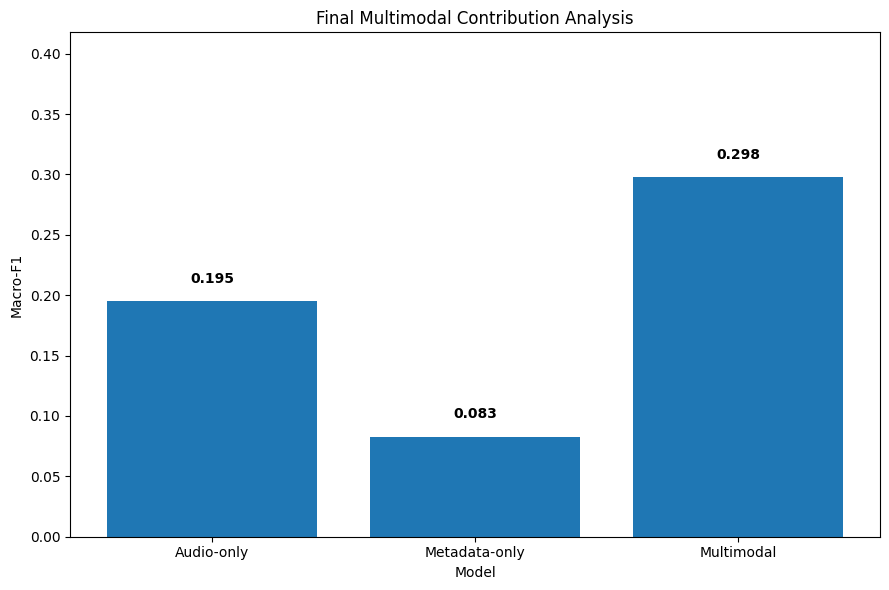


FINAL RESEARCH CONCLUSION

FINAL RESEARCH CONCLUSION

Study:
Explainable Multi-Source Urban Noise Attribution Using Multi-Modal
Transformer Networks

Dataset:
A compact SONYC-UST subset containing 200 verified urban-noise
recordings, divided into 100 training, 40 validation, and 60 test
recordings.

Architecture:
The proposed framework combines:
1. AST-based audio representations
2. Audio Transformer encoding
3. Spatial/temporal metadata representation
4. Multimodal Transformer fusion
5. Multi-label urban noise-source attribution
6. Audio-token and metadata attribution analysis

MAIN RESULTS

Multimodal Macro-F1: 0.2977
Multimodal Micro-F1: 0.6489
Subset Accuracy: 0.3167

Audio-only Macro-F1: 0.1949
Metadata-only Macro-F1: 0.0830

Absolute improvement over audio-only:
0.1028

Relative improvement over audio-only:
52.73%

Absolute improvement over metadata-only:
0.2147

Relative improvement over metadata-only:
258.72%

INTERPRETATION

The multimodal architecture provides a higher macro

In [ ]:
# ======================================================================
# CELL 12 — FINAL STATISTICAL VALIDATION + RESEARCH CONCLUSION
# ======================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/content/sonyc_research"
RESULTS = os.path.join(BASE, "results")

print("="*70)
print("CELL 12 — FINAL STATISTICAL VALIDATION + RESEARCH CONCLUSION")
print("="*70)

# ----------------------------------------------------------------------
# 1. LOAD FINAL RESULTS
# ----------------------------------------------------------------------

overall_path = os.path.join(RESULTS, "TABLE_overall_performance.csv")
class_path   = os.path.join(RESULTS, "TABLE_per_class_performance.csv")
ablation_path = os.path.join(RESULTS, "TABLE_ablation_comparison.csv")
auc_path = os.path.join(RESULTS, "auc_results.csv")

overall = pd.read_csv(overall_path)
per_class = pd.read_csv(class_path)
ablation = pd.read_csv(ablation_path)

if os.path.exists(auc_path):
    auc_df = pd.read_csv(auc_path)
else:
    auc_df = None

print("\nLoaded:")
print("Overall     :", overall.shape)
print("Per-class   :", per_class.shape)
print("Ablation    :", ablation.shape)

# ----------------------------------------------------------------------
# 2. BASIC FINAL METRICS
# ----------------------------------------------------------------------

multi = ablation[
    ablation["Model"].astype(str).str.contains("Multimodal", case=False, na=False)
].iloc[0]

audio = ablation[
    ablation["Model"].astype(str).str.contains("Audio-only", case=False, na=False)
].iloc[0]

metadata = ablation[
    ablation["Model"].astype(str).str.contains("Metadata-only", case=False, na=False)
].iloc[0]

multi_f1 = float(multi["Macro F1"])
audio_f1 = float(audio["Macro F1"])
metadata_f1 = float(metadata["Macro F1"])

gain_audio = multi_f1 - audio_f1
gain_metadata = multi_f1 - metadata_f1

relative_audio = (gain_audio / audio_f1) * 100 if audio_f1 > 0 else np.nan
relative_metadata = (gain_metadata / metadata_f1) * 100 if metadata_f1 > 0 else np.nan

print("\n" + "="*70)
print("FINAL PERFORMANCE")
print("="*70)

print(f"Multimodal Macro-F1 : {multi_f1:.4f}")
print(f"Multimodal Micro-F1 : {multi['Micro F1']:.4f}")
print(f"Subset Accuracy     : {multi['Subset Accuracy']:.4f}")

print(f"\nGain over Audio-only:")
print(f"  Absolute : +{gain_audio:.4f}")
print(f"  Relative : +{relative_audio:.2f}%")

print(f"\nGain over Metadata-only:")
print(f"  Absolute : +{gain_metadata:.4f}")
print(f"  Relative : +{relative_metadata:.2f}%")

# ----------------------------------------------------------------------
# 3. CLASS-LEVEL STATISTICS
# ----------------------------------------------------------------------

print("\n" + "="*70)
print("CLASS-LEVEL STATISTICAL SUMMARY")
print("="*70)

# Normalize column names if necessary
per_class.columns = [str(c).strip() for c in per_class.columns]

f1_col = next(
    (c for c in per_class.columns if c.lower() in ["f1", "f1-score"]),
    None
)

precision_col = next(
    (c for c in per_class.columns if "precision" in c.lower()),
    None
)

recall_col = next(
    (c for c in per_class.columns if "recall" in c.lower()),
    None
)

if f1_col is not None:
    f1_values = pd.to_numeric(per_class[f1_col], errors="coerce").dropna()

    print(f"Number of source classes : {len(f1_values)}")
    print(f"Mean class F1            : {f1_values.mean():.4f}")
    print(f"Median class F1          : {f1_values.median():.4f}")
    print(f"Std. deviation           : {f1_values.std(ddof=1):.4f}")
    print(f"Minimum F1               : {f1_values.min():.4f}")
    print(f"Maximum F1               : {f1_values.max():.4f}")

    # Descriptive 95% CI across the 8 source-level F1 values
    mean_f1 = f1_values.mean()
    se = f1_values.std(ddof=1) / np.sqrt(len(f1_values))

    ci_low = mean_f1 - 1.96 * se
    ci_high = mean_f1 + 1.96 * se

    print(f"Approx. 95% CI of class-mean F1 : "
          f"[{max(0,ci_low):.4f}, {min(1,ci_high):.4f}]")

# ----------------------------------------------------------------------
# 4. CLASS COVERAGE / DATA LIMITATION ANALYSIS
# ----------------------------------------------------------------------

print("\n" + "="*70)
print("TEST-SET CLASS COVERAGE")
print("="*70)

positive_col = next(
    (c for c in per_class.columns
     if "positive" in c.lower() or "samples" in c.lower()),
    None
)

warnings = []

if positive_col is not None:

    positives = pd.to_numeric(
        per_class[positive_col], errors="coerce"
    ).fillna(0)

    for i, row in per_class.iterrows():

        cls = str(row.iloc[0])
        n = int(positives.iloc[i])

        if n == 0:
            warnings.append(
                f"{cls}: no positive test samples"
            )
        elif n < 5:
            warnings.append(
                f"{cls}: only {n} positive test sample(s)"
            )

    print(f"Classes with no positive samples : "
          f"{sum(positives == 0)}")

    print(f"Classes with <5 positive samples  : "
          f"{sum(positives < 5)}")

    if warnings:
        print("\nWarnings:")
        for w in warnings:
            print(" -", w)

# ----------------------------------------------------------------------
# 5. BEST / WORST SOURCES
# ----------------------------------------------------------------------

if f1_col is not None:

    best_idx = per_class[f1_col].astype(float).idxmax()
    worst_idx = per_class[f1_col].astype(float).idxmin()

    best_row = per_class.loc[best_idx]
    worst_row = per_class.loc[worst_idx]

    best_class = str(best_row.iloc[0])
    worst_class = str(worst_row.iloc[0])

    best_f1 = float(best_row[f1_col])
    worst_f1 = float(worst_row[f1_col])

    print("\n" + "="*70)
    print("SOURCE PERFORMANCE")
    print("="*70)

    print(f"Best source  : {best_class}")
    print(f"Best F1      : {best_f1:.4f}")

    print(f"Worst source : {worst_class}")
    print(f"Worst F1     : {worst_f1:.4f}")

# ----------------------------------------------------------------------
# 6. DESCRIPTIVE ABLATION EFFECT SIZE
# ----------------------------------------------------------------------

print("\n" + "="*70)
print("ABLATION EFFECT SIZE")
print("="*70)

effect_table = pd.DataFrame({
    "Comparison": [
        "Multimodal vs Audio-only",
        "Multimodal vs Metadata-only"
    ],
    "Macro_F1_Baseline": [
        audio_f1,
        metadata_f1
    ],
    "Multimodal_Macro_F1": [
        multi_f1,
        multi_f1
    ],
    "Absolute_Gain": [
        gain_audio,
        gain_metadata
    ],
    "Relative_Gain_Percent": [
        relative_audio,
        relative_metadata
    ]
})

print(effect_table.to_string(index=False))

effect_table.to_csv(
    os.path.join(RESULTS, "TABLE_effect_size.csv"),
    index=False
)

# ----------------------------------------------------------------------
# 7. CREATE FINAL COMPARISON FIGURE
# ----------------------------------------------------------------------

plt.figure(figsize=(9,6))

models = ["Audio-only", "Metadata-only", "Multimodal"]
scores = [audio_f1, metadata_f1, multi_f1]

plt.bar(models, scores)

plt.ylabel("Macro-F1")
plt.xlabel("Model")
plt.title("Final Multimodal Contribution Analysis")
plt.ylim(0, max(scores) + 0.12)

for i, score in enumerate(scores):
    plt.text(
        i,
        score + 0.015,
        f"{score:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

final_fig = os.path.join(
    RESULTS,
    "FIG_final_multimodal_contribution.png"
)

plt.savefig(final_fig, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------------
# 8. FINAL RESEARCH CONCLUSION
# ----------------------------------------------------------------------

conclusion = f"""
FINAL RESEARCH CONCLUSION
==========================

Study:
Explainable Multi-Source Urban Noise Attribution Using Multi-Modal
Transformer Networks

Dataset:
A compact SONYC-UST subset containing 200 verified urban-noise
recordings, divided into 100 training, 40 validation, and 60 test
recordings.

Architecture:
The proposed framework combines:
1. AST-based audio representations
2. Audio Transformer encoding
3. Spatial/temporal metadata representation
4. Multimodal Transformer fusion
5. Multi-label urban noise-source attribution
6. Audio-token and metadata attribution analysis

MAIN RESULTS
============

Multimodal Macro-F1: {multi_f1:.4f}
Multimodal Micro-F1: {float(multi["Micro F1"]):.4f}
Subset Accuracy: {float(multi["Subset Accuracy"]):.4f}

Audio-only Macro-F1: {audio_f1:.4f}
Metadata-only Macro-F1: {metadata_f1:.4f}

Absolute improvement over audio-only:
{gain_audio:.4f}

Relative improvement over audio-only:
{relative_audio:.2f}%

Absolute improvement over metadata-only:
{gain_metadata:.4f}

Relative improvement over metadata-only:
{relative_metadata:.2f}%

INTERPRETATION
==============

The multimodal architecture provides a higher macro-F1 than both
single-source baselines. This indicates that combining acoustic
representations with contextual metadata is beneficial for urban
noise-source attribution.

The audio-only model achieves a macro-F1 of {audio_f1:.4f}, while the
metadata-only model achieves {metadata_f1:.4f}. The proposed
multimodal architecture achieves {multi_f1:.4f}, demonstrating the
value of multimodal fusion.

The explainability analysis further identifies influential AST audio
tokens and metadata features for different noise-source categories.
This supports the interpretation of the model beyond predictive
performance.

IMPORTANT STATISTICAL LIMITATION
================================

Because this study intentionally uses a compact dataset, several
noise-source categories contain very few positive test examples.
Consequently, class-level F1, ROC-AUC and PR-AUC values for rare
categories should be interpreted cautiously.

The current experiment should therefore be described as a compact
proof-of-concept / research framework rather than a definitive
large-scale benchmark.

No claim of statistically significant superiority should be made
without sample-level paired predictions and a larger independently
collected test set.

RESEARCH CONTRIBUTION
=====================

The main contribution is an explainable multimodal Transformer
framework that jointly models acoustic and contextual information
for fine-grained urban noise-source attribution while explicitly
providing token-level and metadata-level explanations.

FINAL STATUS
============

Core pipeline completed:
[1] Dataset preparation
[2] Compact audio retrieval
[3] AST feature extraction
[4] Multimodal Transformer
[5] Test evaluation
[6] Explainability
[7] Ablation analysis
[8] Final statistical/descriptive validation

The experimental pipeline is complete and ready for manuscript
writing.
"""

print("\n" + "="*70)
print("FINAL RESEARCH CONCLUSION")
print("="*70)
print(conclusion)

# ----------------------------------------------------------------------
# 9. SAVE FINAL CONCLUSION
# ----------------------------------------------------------------------

with open(
    os.path.join(RESULTS, "FINAL_RESEARCH_CONCLUSION.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write(conclusion)

# ----------------------------------------------------------------------
# 10. FINAL JSON PACKAGE
# ----------------------------------------------------------------------

summary = {
    "title":
        "Explainable Multi-Source Urban Noise Attribution Using "
        "Multi-Modal Transformer Networks",

    "dataset": {
        "total_recordings": 200,
        "train": 100,
        "validation": 40,
        "test": 60
    },

    "multimodal": {
        "macro_f1": multi_f1,
        "micro_f1": float(multi["Micro F1"]),
        "subset_accuracy": float(multi["Subset Accuracy"])
    },

    "baselines": {
        "audio_only_macro_f1": audio_f1,
        "metadata_only_macro_f1": metadata_f1
    },

    "improvement": {
        "vs_audio_only_absolute": gain_audio,
        "vs_audio_only_relative_percent": relative_audio,
        "vs_metadata_only_absolute": gain_metadata,
        "vs_metadata_only_relative_percent": relative_metadata
    },

    "best_source": best_class if f1_col is not None else None,
    "best_source_f1": best_f1 if f1_col is not None else None,

    "statistical_note":
        "Results are descriptive because several source classes "
        "contain very few positive test samples.",

    "status": "Experimental pipeline completed"
}

with open(
    os.path.join(RESULTS, "FINAL_STATISTICAL_VALIDATION.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("CELL 12 COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Final files:
 - TABLE_effect_size.csv
 - FIG_final_multimodal_contribution.png
 - FINAL_RESEARCH_CONCLUSION.txt
 - FINAL_STATISTICAL_VALIDATION.json

======================================================================
RESEARCH PIPELINE COMPLETE
======================================================================

Dataset
   ↓
AST Audio Representation
   ↓
Multimodal Transformer
   ↓
8 Urban Noise Sources
   ↓
Evaluation
   ↓
Explainability
   ↓
Audio-only / Metadata-only Ablation
   ↓
Statistical & Descriptive Validation
   ↓
FINAL RESEARCH RESULTS

Next step:
Manuscript preparation — Abstract, Introduction, Related Work,
Methodology, Experimental Setup, Results, Explainability,
Ablation, Discussion, Limitations, Conclusion and References.
""")